# Liquidez multi-banco — diagnóstico, corrección y política de rebalanceo

Rehacer el notebook del squad para responder la pregunta real: **¿cuándo, cuánto y desde dónde mover dinero
entre 6 cuentas en 3 monedas para minimizar el riesgo de faltante sin mover dinero de más?**

**Cómo leer este notebook.** Toda la lógica vive en [`src/`](../src/) (ingesta, calidad, forecast, políticas, MILP,
backtest) y tiene pruebas (`pytest`, 28 tests). Aquí solo se importa y se muestra. Cada celda de cifras se genera
desde los datos: si cambias un supuesto en [`src/config.py`](../src/config.py) y reejecutas, las tablas y los textos numéricos se actualizan.

| Parte | Qué responde |
|---|---|
| **0** | Supuestos declarados (todo lo que *no* está en los datos) |
| **1** | Qué está mal en el enfoque del squad, con evidencia (D1–D10), y el pipeline corregido |
| **2** | Enfoque propuesto: forecast probabilístico → política de cuantil → MILP → backtest con frontera costo–riesgo |
| **3** | Dos explicaciones: para el data scientist y para Tesorería |
| **4 / 5** | Formas de trabajo (uso de IA) y productivización |

> **Tiempo de ejecución:** ~5–6 min (el backtest resuelve un MILP por día y por política).

## Índice

  - 0 · Supuestos declarados
- Parte 1 · Diagnóstico y corrección del enfoque del squad
  - 1.1 Punto de partida: el notebook del squad, reproducido
  - 1.2 Los datos: qué está roto y cómo se corrige
    - D1 · `dropna` silencioso tras `coerce`: el squad pierde el 17,6% de la historia
    - El pipeline corregido (`src/ingest.py`) y su reporte de calidad
    - D2 · Duplicados y errores de signo/escala nunca detectados → el forecast del squad se contamina durante 14 días
    - D3 · 9 etiquetas de moneda tratadas como distintas
    - D4 · El forecast es la media móvil 14d del **nivel**: sin drift, sin estacionalidad, sin horizonte
    - D4b · Estacionalidad semanal: identificarla antes de modelarla
      - D4b-1 · Ver la estacionalidad antes de probarla
      - D4b-2 · ACF / PACF: ¿hay que diferenciar? ¿dónde está la estacionalidad?
    - D4c · Validación con `TimeSeriesSplit` y un forecast ETS
    - D4d · XGBoost con rezagos: ¿sobreestima, subestima o queda balanceado (±15%)?
    - D4e · El reto: un modelo por cuenta (no uno global), afinado — ¿mejora el MAPE?
    - D4f · Pronóstico de los últimos 14 días del dataset, todos los modelos lado a lado
    - D5 · Sin incertidumbre
    - D6 · Donante = `idxmax()` del balance **nominal**, sin convertir moneda
    - D7 · Umbrales fijos inventados, solo para 4 de 6 cuentas
    - D8 y D9 · `transfer_today: True` ignora el lag; los fees se ignoran
    - D10 · Validación circular: promedio de saldos antes/después del 1-mayo, sumando COP+USD+MXN
- Parte 2 · Un enfoque sólido a la pregunta real
  - 2.0 Formulación (qué significa "faltante" y cómo se decide) — **pendiente en este borrador**
  - 2.1 Reconciliación: ¿el log de transferencias explica algo de los saldos? — **pendiente**
  - 2.2 Estructura de los flujos — **pendiente**
  - 2.3 Forecast probabilístico: escalera de modelos con backtest walk-forward
  - 2.4–2.7 (resumen) · Piso operativo, políticas de cuantil y MILP, backtest, fee vs. multa
  - 2.8 Motor de rebalanceo: cuándo, cuánto y desde dónde (trigger + sizing, formalización)
    - Caso real: 2025-05-06
  - 2.9 Sensibilidad — **pendiente**
  - 2.10 Dónde puede seguir fallando — **pendiente**
- Parte 3 · Dos explicaciones de lo mismo — **pendiente**
  - 3.1 Para el data scientist del squad
  - 3.2 Para Tesorería
- Parte 4 · Formas de trabajo: dónde se usó IA y dónde no — **pendiente**
- Parte 5 · De notebook a producción (media página) — **pendiente**
- Decisiones abiertas y verificación — **pendiente**
  (el Resumen ejecutivo dice "la última celda verifica esto"; hoy esa celda no existe)

## Resumen ejecutivo

*(cifras del run de este notebook; la última celda verifica que se cumplan)*

- **El "parece funcionar" del squad es falso.** Su pipeline pierde el 17,6% de las filas, trata 9 etiquetas como 9 monedas, deja pasar 7 lecturas corruptas y 6 episodios inexplicables, elige el donante por saldo *nominal* sin convertir moneda, y "valida" con un promedio antes/después que suma COP+USD+MXN (−9,6% presentado como éxito).
- **Datos corregidos con la identidad contable** (`b[t]=b[t-1]+in−out`): panel 6 × 270, 0 nulos, 0 negativos, residuo ≈ 0,01. Lo inexplicable va a cuarentena marcada, no se adivina.
- **Forecast del flujo neto, con distribución.** Todos los modelos ganan ~26–34% al naive estacional, pero **ninguno gana a un bootstrap empírico** (la media del flujo neto casi no tiene señal): el valor está en los cuantiles, con cobertura p5–p95 de ~93%.
- **Backtest con contrafactual** (210 días × 6 cuentas, piso = 25 días de egresos): sin intervenir hay **33 días-cuenta en faltante**; la regla del squad, **86** (peor que nada, USD 6,3 mil, 200 transferencias); la política de cuantil, **0** (USD 5,0 mil, 49 transferencias); el **MILP, 0** (USD 2,1 mil, 22 transferencias, todas de la misma moneda — de hecho, dentro de 3 pools operativa-reserva fijos, ver 2.7). El MILP también *decide no mover dinero* cuando operar cuesta más que la penalización esperada.
- **Sensibilidad:** robusto a FX ±10% y a lag forzado; **frágil a un forecast sesgado** (aparecen 1–3 días en faltante); con un piso de 30 días el sistema no tiene liquidez suficiente y el problema es de fondeo, no de rebalanceo.
- **Pendiente de decisión humana:** piso (K), FX oficial del COP, costo fijo, penalización, los 6 episodios sin explicar y qué representa el log de transferencias (que **no aparece en los saldos**). Ver el final del notebook.
- **Estacionalidad y validación temporal (D4b–D4d, Anexo A).** El patrón semanal está en las entradas y salidas, no en el saldo (paseo aleatorio con deriva: `d = 1`); XGBoost con rezagos no supera de forma clara al "último saldo" (gana en 18 de 30 bloques). Redundante con 2.3, por eso queda en el anexo.
- **Regla sencilla de espera (2.7b).** Esperar cuando el faltante solo está en la cola y aún hay holgura baja las transferencias de 49 a 13 y el costo de USD 4.955 a USD 2.555, pero deja 3 días-cuenta en faltante; el MILP logra 0 faltantes con USD 2.099. La regla sirve para identificar oportunidades y explicar la decisión, no para reemplazar al MILP.

In [1]:
import sys
from pathlib import Path

# el notebook vive en notebooks/: se sube hasta encontrar la carpeta src/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as cfg, ingest, quality, features, diagnosis as D
from src import forecast as F, policy as P, optimize as O, backtest as B, plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

## 0 · Supuestos declarados

Todo lo que **no es observable en los datos** está aquí y en [`src/config.py`](../src/config.py); ninguna constante de negocio vive en el código.
Los marcados **[DECISIÓN HUMANA]** son valores por defecto razonables, **pendientes de validación por Tesorería**; el backtest los
somete a sensibilidad (Parte 2.8) precisamente para no depender de ellos a ciegas.

**Piso operativo (K × egreso medio de 28 días).** No viene del enunciado del caso ni de `SPEC_caso_liquidez.md`: es un supuesto propio, elegido por solvencia agregada
del sistema — K=25 porque con K=30 el excedente agregado mínimo del sistema cae a ~USD 58 mil y el problema deja de ser de rebalanceo (detalle en 2.4, sensibilidad en 2.8).
Define qué es "faltante" en toda política, backtest y optimización del notebook; **pendiente de validación por Tesorería**.

**Penalización por déficit (`cfg.DEFICIT_PENALTY_PER_DAY` = 0,2% del déficit por cuenta-día, `cfg.PENALTY_WEIGHT` = 1,0 operativa / 0,5 reserva).**
Es el precio que le pone este notebook a "quedar bajo el piso", y con eso decide en 2.6/2.7/4.4 si es más barato transferir (fee + `cfg.FIXED_COST_USD` = USD 25 fijos) o
absorber la multa. **No sale de los datos ni del enunciado**, y el propio comentario en `src/config.py` es explícito sobre su origen: se fijó en la
*rodilla* de la frontera costo-riesgo del backtest (2.8) — **después** de ver esa frontera, no antes — así que es una elección en muestra, sin validar
fuera de ella. El análisis "¿es más barato pagar la multa que el fee?" (2.7) es tan bueno como este número; **pendiente de validación por Tesorería**
igual que el piso.

In [2]:
cfg.assumptions_table()

,supuesto,valor,origen / nota
0,FX (unid. por USD),"{'USD': 1.0, 'MXN': 18.4457, 'COP': 3900.0}","[DECISIÓN HUMANA] MXN: FIX Banxico 26-sep-2025 = 18,4457. COP: aproximado ~3.900, pendiente de sustituir por la TRM oficial (Banco de la..."
1,Fee variable,"{'same_ccy': 0.0004, 'cross_ccy': 0.0027}","Observado en el log: misma moneda 0,04% fijo; cross 0,15-0,40%"
2,Lag observado,"{'same_ccy': {0: 20, 1: 5}, 'cross_ccy': {1: 37, 2: 57, 3: 26}}",Observado en el log
3,Lag de planificación,"{'same_ccy': 1, 'cross_ccy': 3}",p90 por tipo (conservador)
4,Costo fijo por operación (USD),25.0,[DECISIÓN HUMANA] no observable
5,Penalización por déficit,0.20% del déficit por cuenta-día,[DECISIÓN HUMANA] define el punto en la frontera
6,Ponderación penalización,"{'operational': 1.0, 'reserve': 0.5}",operativa > reserva como destino
7,Piso operativo,"{'operational': 25.0, 'reserve': 25.0} días de egresos medios (28d)",[DECISIÓN HUMANA] define qué es 'faltante'
8,Monto mínimo de transferencia,1.0 día(s) de egresos del destino,evita goteo de micro-operaciones
9,Horizonte de decisión,"14 días, reoptimización diaria",spec §7


---
# Parte 1 · Diagnóstico y corrección del enfoque del squad

## 1.1 Punto de partida: el notebook del squad, reproducido

Se reejecuta **su código, sin tocarlo**, sobre el crudo. Es la evidencia sobre la que se diagnostica.

In [3]:
accounts = ingest.load_accounts()
raw_squad = ingest.load_raw_balances()          # el crudo, con la fecha como texto
transfers_raw = ingest.load_raw_transfers()

squad = D.squad_pipeline(accounts, raw_squad)   # coerce + dropna, media de 14 filas, umbral fijo, idxmax
print("filas que sobreviven en el pipeline del squad:", squad["balances"].shape[0], "de", len(raw_squad))
print("etiquetas de moneda 'distintas':", sorted(squad["balances"]["currency"].unique()))
print("\nforecast del squad (un escalar constante para los 7 días):")
print({k: f"{v:,.0f}" for k, v in squad["forecasts"].items()})
print("\nrecomendaciones del squad:")
pd.DataFrame(squad["recommendations"])

filas que sobreviven en el pipeline del squad: 1375 de 1668
etiquetas de moneda 'distintas': ['COP', 'Colombian Peso', 'MXN', 'Mexican Peso', 'US Dollar', 'USD', 'cop', 'mxn', 'usd']

forecast del squad (un escalar constante para los 7 días):
{'ACC-001': '2,305,518,572', 'ACC-002': '79,790', 'ACC-003': '2,920,535,273', 'ACC-004': '15,965,982', 'ACC-005': '107,312,810', 'ACC-006': '151,186'}

recomendaciones del squad:


,to_account,from_account,amount_needed,transfer_today
0,ACC-002,ACC-003,"20,210.32",True
1,ACC-004,ACC-003,"24,034,018.22",True


## 1.2 Los datos: qué está roto y cómo se corrige

El hallazgo que ordena todo: **los datos traen su propia llave de respuesta, la identidad contable**

> `balance[t] = balance[t-1] + inflow[t] − outflow[t]`

Cuadra al centavo en toda fila sana. Eso permite *elegir* el duplicado correcto (no promediar), *reconstruir* nulos de forma exacta,
*reparar* solo lo que tiene firma exacta (−1× o 10×) y *poner en cuarentena* —marcado y reportado— lo que no se puede explicar.

### D1 · `dropna` silencioso tras `coerce`: el squad pierde el 17,6% de la historia

In [4]:
loss = D.parse_loss_by_format(raw_squad)
display(loss)
lost = int(loss["perdidas"].sum())
print(f"El comentario del squad decía 'a few dates don't parse'. Son {lost} de {len(raw_squad)} filas = {lost/len(raw_squad):.1%}: "
      "TODA fecha que no sea ISO desaparece, y nadie fue avisado.")

,filas,sobreviven,perdidas
formato,,,
%Y-%m-%d,1375,1375,0
%d/%m/%Y,170,0,170
%m-%d-%Y,123,0,123


El comentario del squad decía 'a few dates don't parse'. Son 293 de 1668 filas = 17.6%: TODA fecha que no sea ISO desaparece, y nadie fue avisado.


### El pipeline corregido (`src/ingest.py`) y su reporte de calidad

In [5]:
data = ingest.run_pipeline()            # F1 completo; escribe data/processed/
panel, ledger, transfers = data["panel"], data["ledger"], data["transfers"]
quality.quality_report(data["raw"], ledger, panel, transfers_raw, data["transfers_excluded"])

,problema,afectados,tratamiento
0,Filas entrantes (crudo),"1,668.00",—
1,P1 fechas que el parser del squad pierde,293.00,cascada de 3 formatos: 0 no parseadas
2,P2 etiquetas de moneda (deben ser 3),9.00,normalizadas a ISO-4217 y validadas vs accounts.csv
3,P2 filas con etiqueta no canónica,187.00,→ moneda de la cuenta
4,"P3 pares (fecha, cuenta) duplicados con balance distinto",44.00,se conserva la fila que cuadra con la identidad
5,P3 pares duplicados exactos/ambos nulos,4.00,se colapsan; balance por identidad
6,P4 nulos en balance,68.00,reconstruidos por identidad
7,P4 nulos en inflow,65.00,recuperados por identidad o imputados (marca)
8,P4 nulos en outflow,65.00,recuperados por identidad o imputados (marca)
9,P5 balances negativos en el crudo,4.00,todos sign-flip exacto (-1x) → reparados


**Criterios de aceptación de F1**, verificados por `ingest.validate_panel` (falla si algo no cumple) y por `tests/test_ingest.py`:
1.668 filas leídas → 0 fechas sin parsear · 6 cuentas × 270 días = 1.620 filas sin huecos de calendario · 0 balances negativos · 0 nulos ·
la identidad contable cuadra en el 100% de los días (residuo máx. ≈ 0,01 unidades).

Tres cosas que este análisis **corrige respecto del spec**, porque los datos las contradicen:

1. **No son 4 errores puntuales sino 7** (4 signos invertidos y 3 decimales corridos ×10), **más 6 episodios de 3 días** (65–85% de caída y rebote) que
   *ninguna* regla explica: los flujos registrados no los justifican ni tampoco el log de transferencias. No se adivinan: se
   **ponen en cuarentena** (puente lineal entre el último y el primer saldo confiables, `reliable = False`) y se preguntan a la fuente.
2. **Los 4 negativos son datos, no faltantes**: tras repararlos, ninguna cuenta queda negativa jamás. El "ACC-004 sale negativo" del squad no es ruido ni sobregiro real.
3. **Hay 5 transferencias duplicadas** en el log (todo igual salvo `transfer_id`), que se excluyen y reportan.

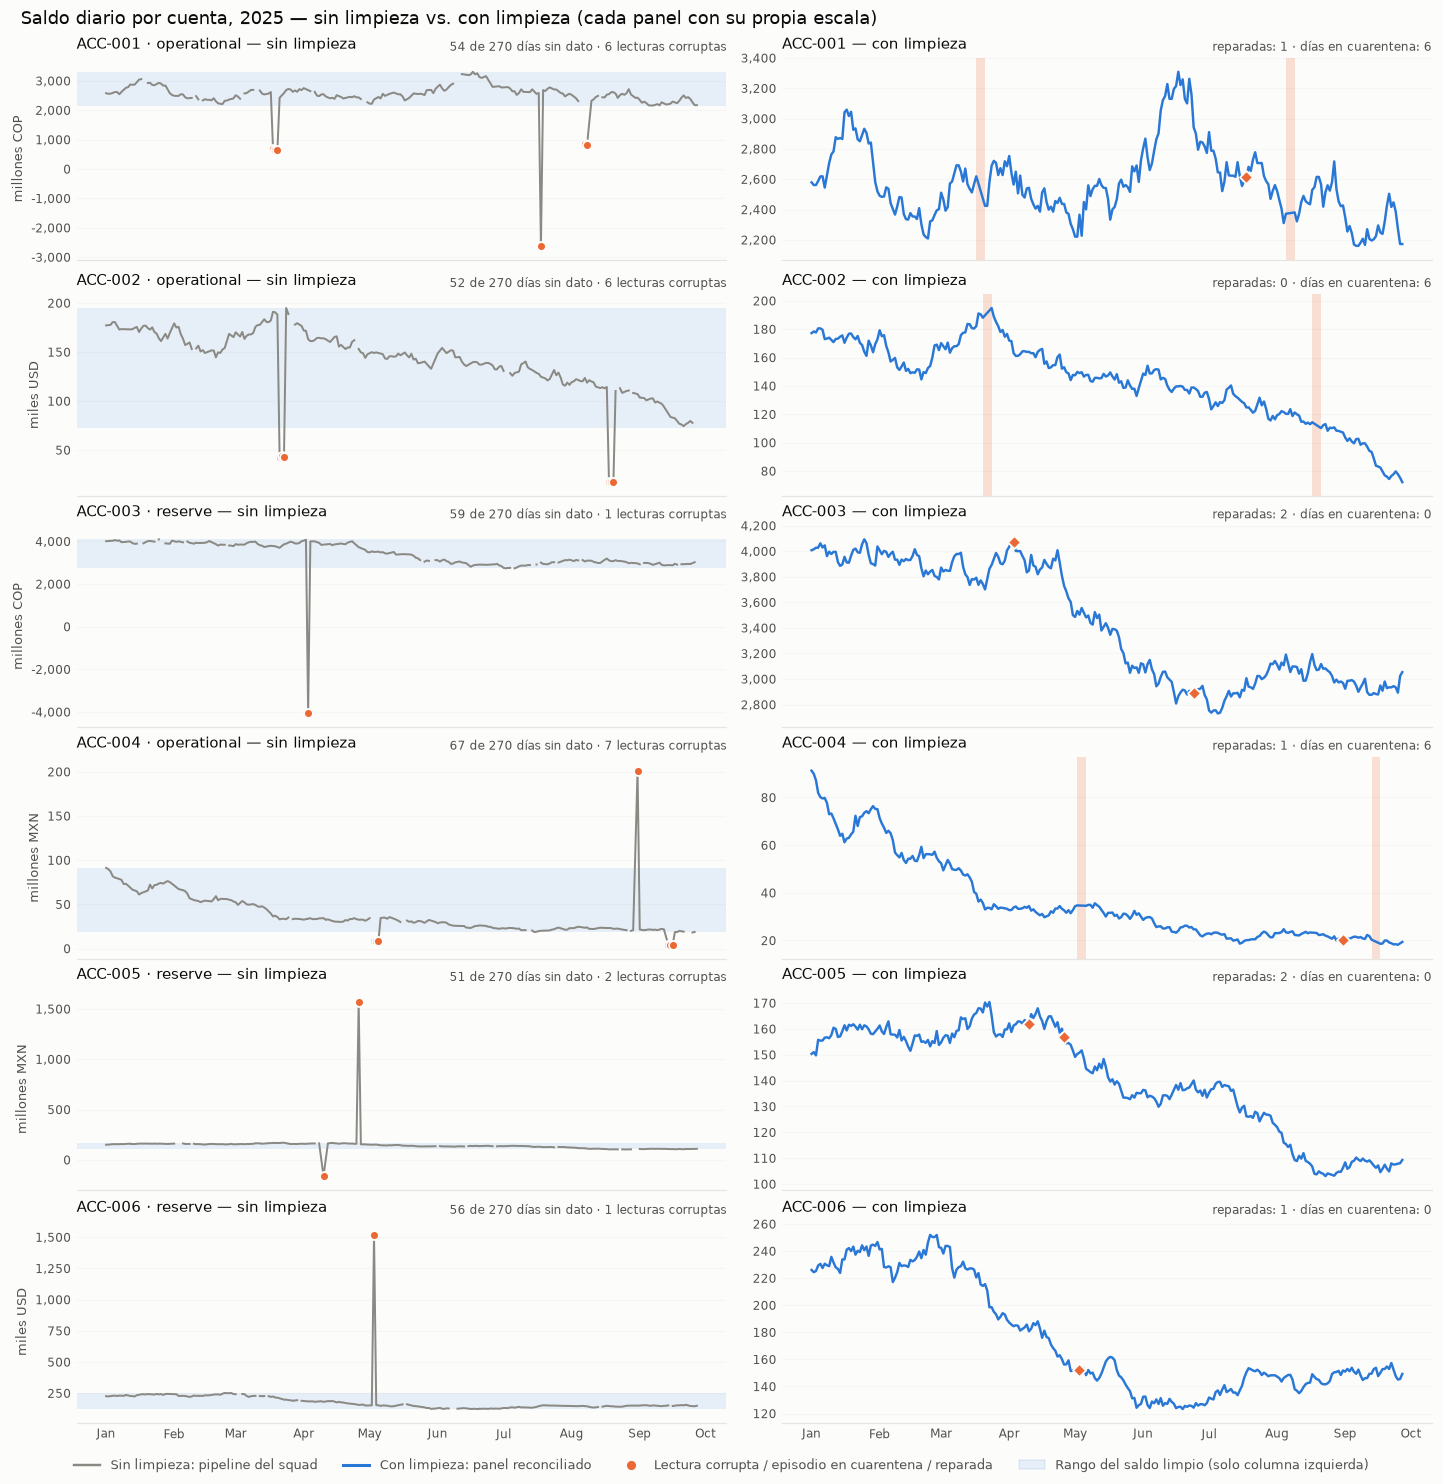

In [6]:
fig = plots.fig_cleaning(data["raw"], panel)
plt.show()

### D2 · Duplicados y errores de signo/escala nunca detectados → el forecast del squad se contamina durante 14 días

Un solo dato malo permanece 14 días dentro de una media móvil de 14. Se compara **el mismo forecast del squad** sobre sus datos
vs. sobre los datos corregidos (aísla el efecto de los *datos* del efecto del *método*):

In [7]:
flows = F.net_flow_matrix(panel)
book = P.Book.from_panel(panel)
store = B.ForecastStore(flows, "empirical")          # forecast por origen, sin lookahead, compartido por todas las políticas

contam = D.contamination_table(squad["balances"], panel)
display(contam)
print(f"Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: {int(contam['dias_con_desvio>10%'].sum())} "
      f"(desvío máximo {contam['desvio_max_%'].max():.0f}%).")

,dias_comparados,dias_con_desvio>10%,desvio_max_%,alertas_con_datos_squad,alertas_con_datos_limpios
account_id,,,,,
ACC-001,101,20,15.04,0.00,0.00
ACC-002,140,7,17.19,11.00,10.00
ACC-003,92,14,14.79,NaN,NaN
ACC-004,126,8,55.64,72.00,73.00
ACC-005,112,16,68.44,NaN,NaN
ACC-006,118,11,65.60,0.00,0.00


Días en que el forecast del squad se aleja >10% del forecast sobre datos limpios: 76 (desvío máximo 68%).


Eso es el "**el forecast de ACC-004 a veces sale disparatado día a día**" del squad: no es ruido a suavizar —como iban a hacer— sino
datos corruptos entrando a una ventana. Añadir suavizado habría empeorado el problema.

### D3 · 9 etiquetas de moneda tratadas como distintas
Se ve en su propio `unique()` de la celda 3 (arriba: 9 etiquetas para 3 monedas). Cada cuenta usa solo variantes de *su* moneda
(0 filas en moneda equivocada), así que es un problema de etiquetas: `accounts.csv` es la fuente de verdad y se normaliza a ISO-4217 con validación cruzada.

### D4 · El forecast es la media móvil 14d del **nivel**: sin drift, sin estacionalidad, sin horizonte
Los saldos de las 6 cuentas **derivan a la baja** (flujo neto medio negativo); una media de niveles pasados los sobreestima siempre.
Backtest (origen diario, saldo a 7 y 14 días, datos limpios) del pronóstico del squad frente a la referencia más ingenua posible: *"el saldo de mañana = el de hoy"*.

* mae_squad — error absoluto medio del pronóstico del squad (media móvil de 14 días) contra el saldo real h días después. Cuanto más alto, peor.
* mae_ultimo — error absoluto medio de la referencia ingenua "el saldo de hoy será el mismo en h días" (sin ningún modelo).
* mae_propuesto — error absoluto medio de tu forecast (mediana del bootstrap empirical) contra el mismo saldo real.

---------------------*****-------------------------*****------------------
* ultimo/squad — mae_ultimo / mae_squad. Es el ratio que vuelve la comparación independiente de la escala (COP vs USD vs MXN). Si vale 1,0 los dos métodos empatan; < 1 significa que "el saldo de hoy" es mejor pronosticador que el squad; > 1 que el squad gana.

* propuesto/squad — el mismo ratio pero para tu forecast propuesto. También muy por debajo de 1: tu método le gana al squad por margen más amplio todavía.

* sesgo del squad (+ = sobreestima) — a diferencia de las anteriores, esta no usa valor absoluto: es el error promedio con signo (pronóstico − real).


mae_squad     mae_ultimo  mae_propuesto  ultimo/squad  propuesto/squad  sesgo del squad (+ = sobreestima)
h  account_id                                                                                                               
7  ACC-001    179,408,073.19 137,165,073.24 143,615,386.78          0.76             0.80                       7,746,898.17
   ACC-002          9,500.29       6,796.28       6,478.85          0.72             0.68                           5,493.17
   ACC-003    129,723,808.16  97,802,766.88  99,773,467.94          0.75             0.77                      60,659,253.84
   ACC-004      2,974,378.23   2,021,411.63   2,435,063.88          0.68             0.82                       2,256,230.81
   ACC-005      5,886,343.94   4,215,279.77   4,216,991.12          0.72             0.72                       3,226,604.10
   ACC-006         10,780.42       7,373.04       7,593.39          0.68             0.70                           5,981.74
14 ACC-001    211,568,637.59 200,816,478.21 213,798,150.73          0.95             1.01                      22,611,433.21
   ACC-002         12,362.45       9,900.57       8,812.94          0.80             0.71                           8,599.95
   ACC-003    175,570,989.21 146,488,568.83 139,088,867.13          0.83             0.79                      96,740,113.86
   ACC-004      4,108,598.97   3,106,893.16   4,148,441.02          0.76             1.01                       3,318,478.52
   ACC-005      7,791,329.40   6,507,568.86   6,444,649.24          0.84             0.83                       5,242,640.74
   ACC-006         15,271.81      11,517.85      12,024.79          0.75             0.79                           8,974.21

'Último saldo' le gana al forecast del squad en 100% de las combinaciones cuenta × horizonte (error 23% menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).


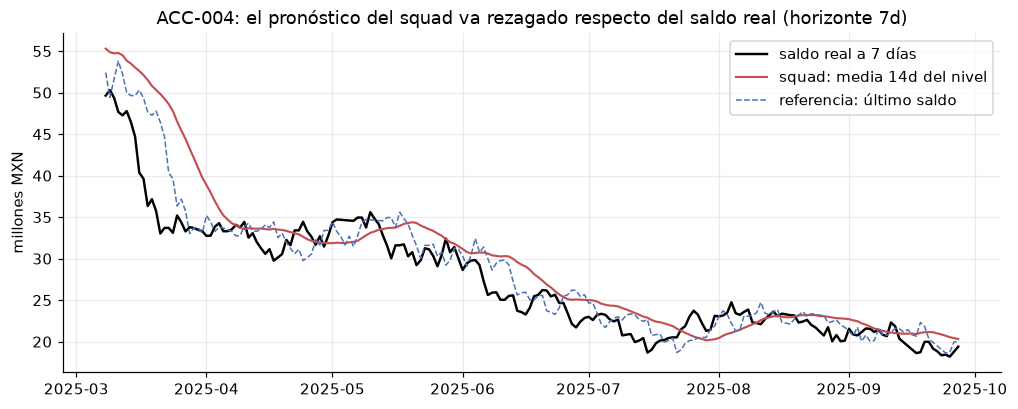

In [8]:
lvl, lvl_series = D.level_forecast_backtest(panel, store)
show = lvl[["account_id", "h", "mae_squad", "mae_ultimo", "mae_propuesto", "mae_ultimo_rel", "mae_propuesto_rel", "sesgo_squad"]].copy()
show = show.rename(columns={"mae_ultimo_rel": "ultimo/squad", "mae_propuesto_rel": "propuesto/squad", "sesgo_squad": "sesgo del squad (+ = sobreestima)"})
display(show.set_index(["h", "account_id"]))
better = (lvl["mae_ultimo"] < lvl["mae_squad"]).mean()
print(f"'Último saldo' le gana al forecast del squad en {better:.0%} de las combinaciones cuenta × horizonte "
      f"(error {(1 - lvl['mae_ultimo_rel']).mean():.0%} menor en promedio), y el squad sobreestima siempre (sesgo > 0 en todas).")
fig = plots.fig_squad_forecast(lvl_series, "ACC-004", 7); plt.show()

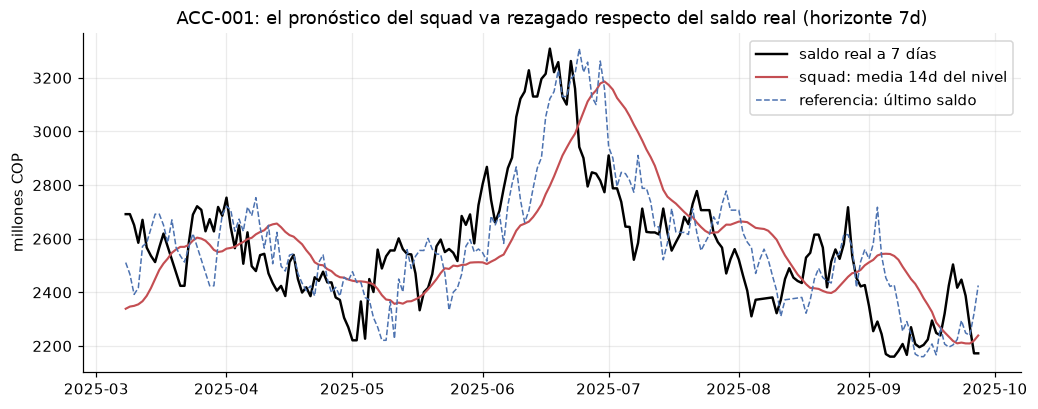

In [9]:
fig = plots.fig_squad_forecast(lvl_series, "ACC-001", 7); plt.show()

Lectura honesta: **a nivel puntual el mejor pronosticador del saldo es "el último saldo"** (paseo aleatorio con deriva), no algo sofisticado —lo verifica la
Parte 2. Nuestro aporte no es más precisión puntual sino **la distribución** (D5). El squad, encima, pronostica *peor que no pronosticar*.

Antes de seguir con D5, un desvío técnico completo — vale la pena mostrarlo entero, no resumido: ¿hay estructura semanal explotable en el saldo? ¿Ayuda modelar con rezagos (XGBoost) en vez de con ETS? ¿Y un modelo por cuenta, afinado con Optuna, le gana a uno global? **D4b–D4e** responde las tres, de principio a fin.

### D4b · Estacionalidad semanal: identificarla antes de modelarla

La media móvil ignora la tendencia y la semana. Antes de meter estacionalidad en un modelo hay que **comprobar que existe y en qué serie**. El saldo es el flujo neto acumulado, así que su estacionalidad equivale a la del `net_flow`: se analizan `inflow`, `outflow` y `net_flow`.

La decisión la toma un test de hipótesis (**Kruskal-Wallis** entre los 7 días de la semana, nivel 1%). La fuerza STL, la autocorrelación en el rezago 7 y el periodograma son evidencia de apoyo. Ojo: STL extrae "estacionalidad" incluso del ruido (con n = 270 el ruido blanco da ~0,20, p95 ~0,29), así que un valor en ese rango no prueba nada.

In [10]:
from src import seasonality, tscv

rep = seasonality.weekly_seasonality_report(panel)
view = rep.assign(kruskal_p=rep["kruskal_p"].map("{:.2g}".format)).rename(columns={
    "fuerza_stl_7": "fuerza STL(7)", "acf_rezago_7": "ACF(7)", "banda_95": "±banda 95%",
    "periodo_dominante": "periodo dominante (días)", "kruskal_p": "p Kruskal (día de semana)", "semanal": "¿semanal?"})
display(view)
display(rep["semanal"].unstack("serie")[["inflow", "outflow", "net_flow"]].rename_axis(columns="¿patrón semanal significativo?"))

fuerza STL(7)  ACF(7)  ±banda 95%  periodo dominante (días) p Kruskal (día de semana)  ¿semanal?
account_id serie                                                                                                     
ACC-001    inflow             0.27    0.06        0.12                      6.92                    0.0011       True
           outflow            0.33    0.19        0.12                      7.11                   1.2e-06       True
           net_flow           0.22    0.08        0.12                      8.18                      0.15      False
ACC-002    inflow             0.24    0.09        0.12                      3.51                   9.1e-06       True
           outflow            0.22    0.06        0.12                      3.51                   9.1e-08       True
           net_flow           0.21   -0.05        0.12                      3.75                      0.42      False
ACC-003    inflow             0.61    0.45        0.12                      6.92                   1.2e-20       True
           outflow            0.58    0.46        0.12                      6.92                   5.5e-23       True
           net_flow           0.24   -0.01        0.12                      4.82                      0.89      False
ACC-004    inflow             0.25    0.21        0.12                    270.00                   2.1e-05       True
           outflow            0.04    0.15        0.12                    270.00                      0.53      False
           net_flow           0.00   -0.10        0.12                     30.00                      0.54      False
ACC-005    inflow             0.45    0.36        0.12                      6.92                   3.5e-14       True
           outflow            0.56    0.49        0.12                      6.92                     2e-22       True
           net_flow           0.17    0.01        0.12                      2.18                      0.82      False
ACC-006    inflow             0.39    0.32        0.12                      6.92                   7.4e-12       True
           outflow            0.35    0.30        0.12                      6.92                   8.2e-12       True
           net_flow           0.20    0.03        0.12                      2.13                      0.59      False

¿patrón semanal significativo?,inflow,outflow,net_flow
account_id,,,
ACC-001,True,True,False
ACC-002,True,True,False
ACC-003,True,True,False
ACC-004,True,False,False
ACC-005,True,True,False
ACC-006,True,True,False


**Lectura.**

- **Entradas y salidas sí tienen patrón semanal:** es significativo en 11 de 12 series (p entre 1e-23 y 1e-3). La única excepción es el egreso de ACC-004 (p = 0,53). El periodograma da ~6,9–7,1 días en ACC-001, 003, 005 y 006; en ACC-002 da 3,5 (un armónico de 7) y en ACC-004 gana la tendencia (270).
- **El flujo neto no lo tiene:** 0 de 6 significativas (p entre 0,15 y 0,89). Su fuerza STL (0,00–0,24) es lo que STL extrae del ruido blanco (~0,20), no una señal.
- **Por qué:** las entradas y las salidas caen juntas el fin de semana y se cancelan en el neto. Como el saldo es el neto acumulado, **el patrón semanal existe en los flujos brutos pero no en el saldo**.

Consecuencia para el modelo: un ETS del saldo con estacionalidad semanal no debería aportar; la estacionalidad identificada solo puede ayudar si se modela en `inflow` y `outflow` por separado. Se prueban las dos cosas abajo.

#### D4b-1 · Ver la estacionalidad antes de probarla

Antes de lanzar ADF/KPSS y el ACF/PACF conviene **mirar** las series. Para cada cuenta y para cada serie (saldo, entradas y salidas) se dibuja el perfil medio en tres ciclos:

- **Semanal:** día de la semana (lunes a domingo).
- **Quincenal:** día dentro de la quincena (1 a 15 en la primera, 16 a 31 pasan a 1 a 16 en la segunda), para ver efectos de día de pago.
- **Mensual:** día del mes (1 a 31).

Cada perfil es la desviación % respecto de la tendencia (media móvil centrada de 28 días; sin quitarla, la deriva del saldo taparía todo), con una banda de ±1,96 errores estándar y el p-valor de Kruskal-Wallis arriba a la derecha (en naranja si p < 0,01). **Si la banda cubre el 0 casi en todas las posiciones, no hay patrón distinguible del ruido.**

Límites: con ~9 meses, cada día de la semana tiene ~38 observaciones, cada posición de la quincena ~17 y cada día del mes ~9, así que el ciclo mensual es el menos fiable; y un ciclo por mes del año necesita más de un año de historia.

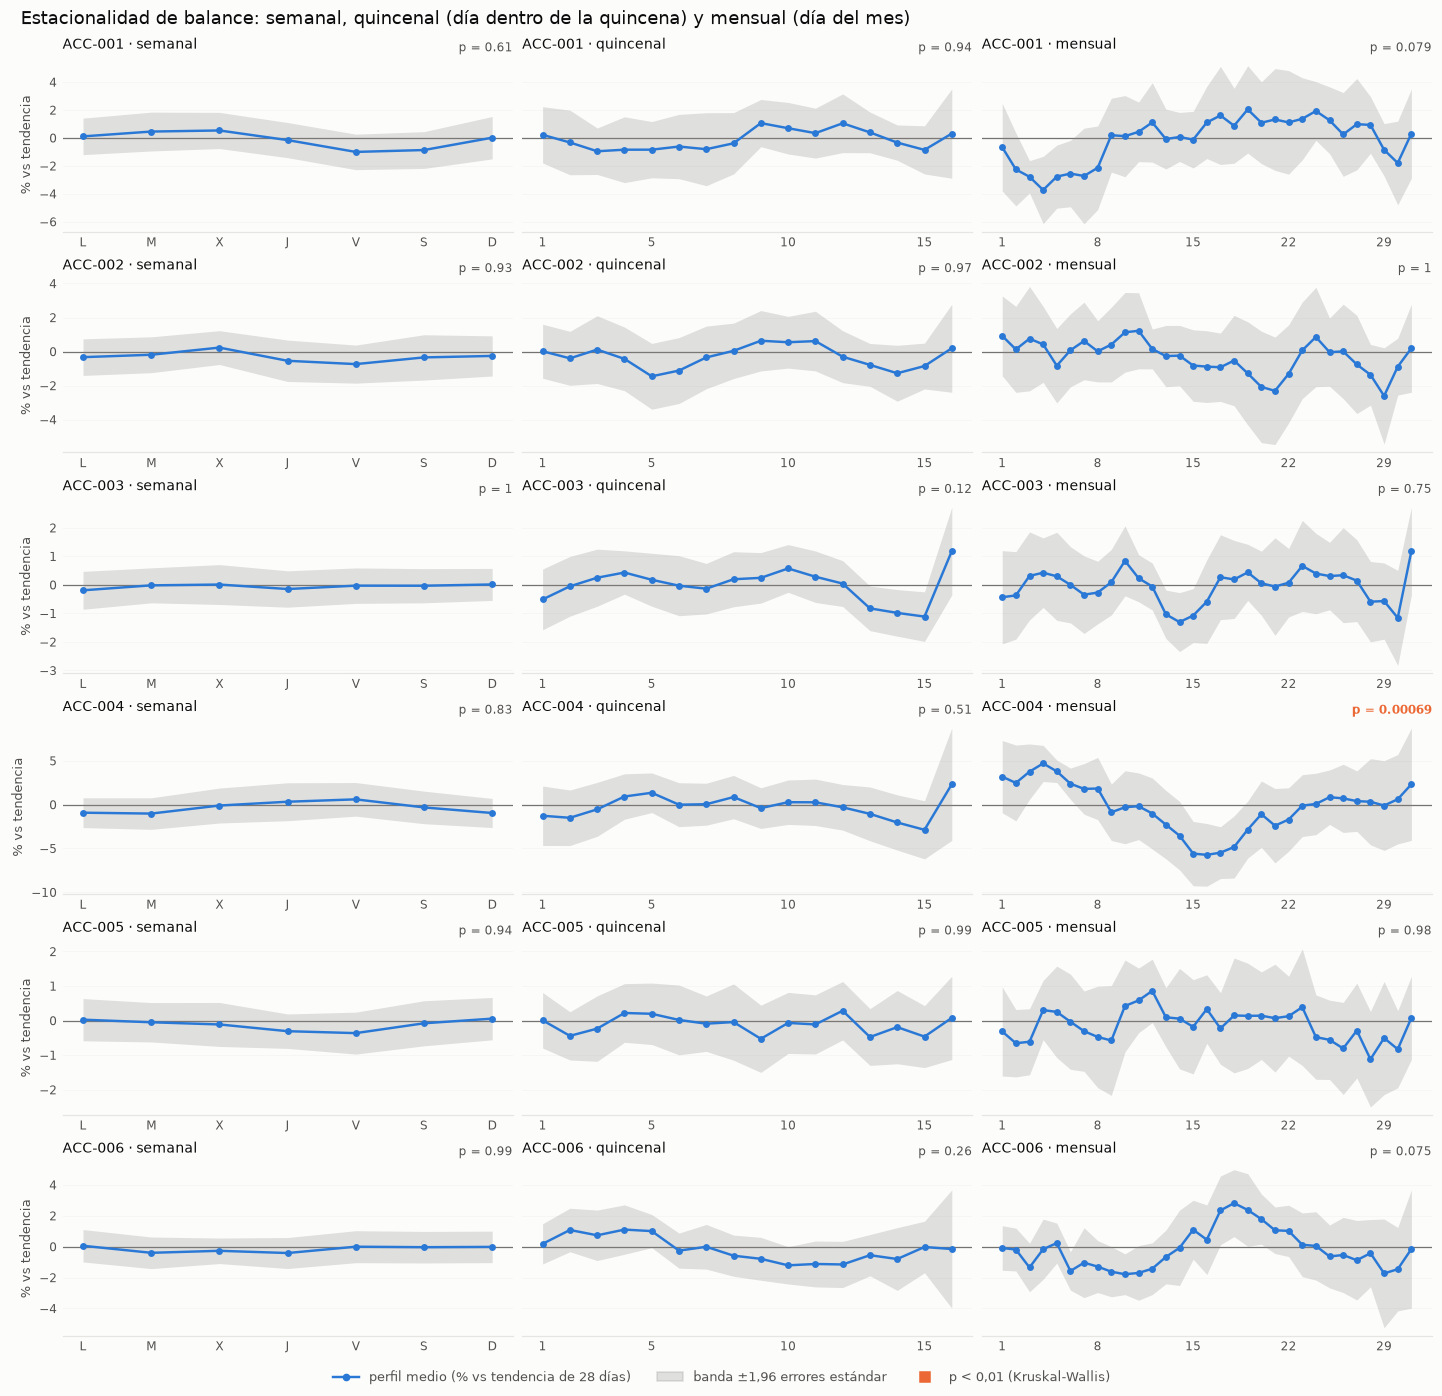

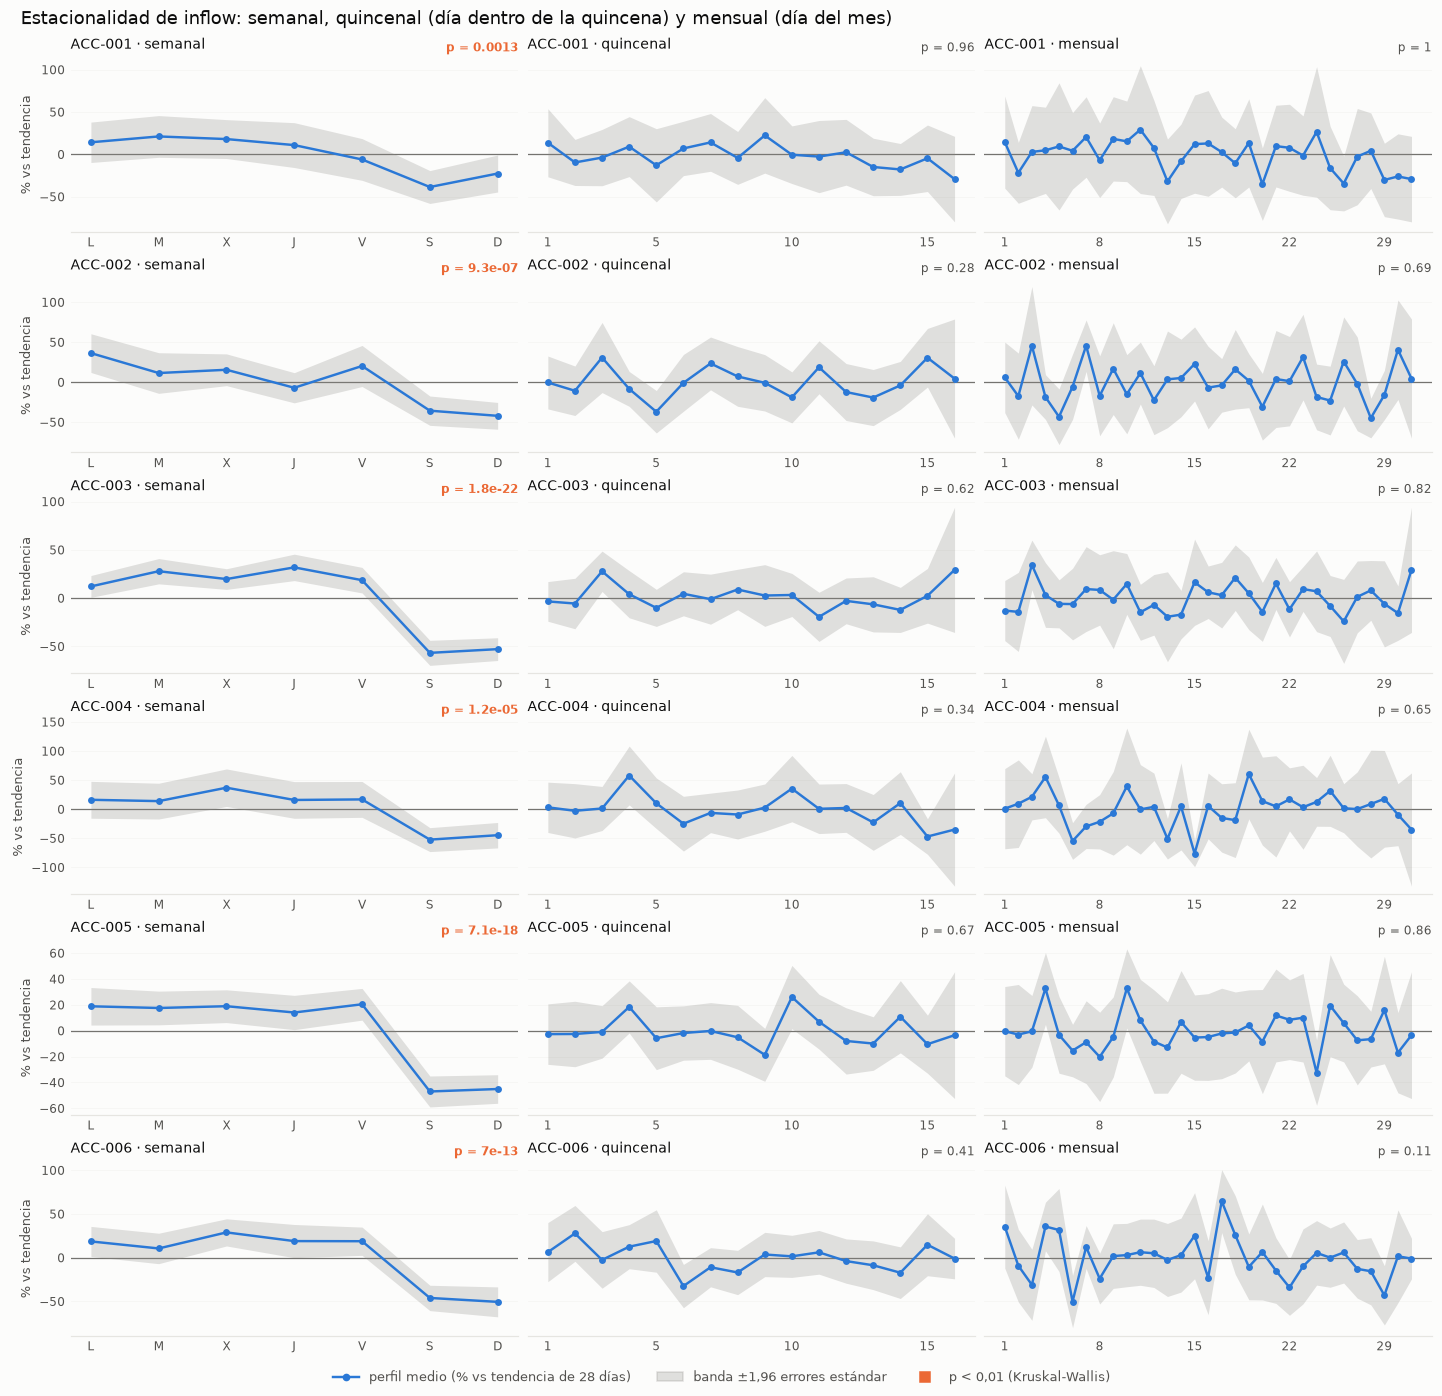

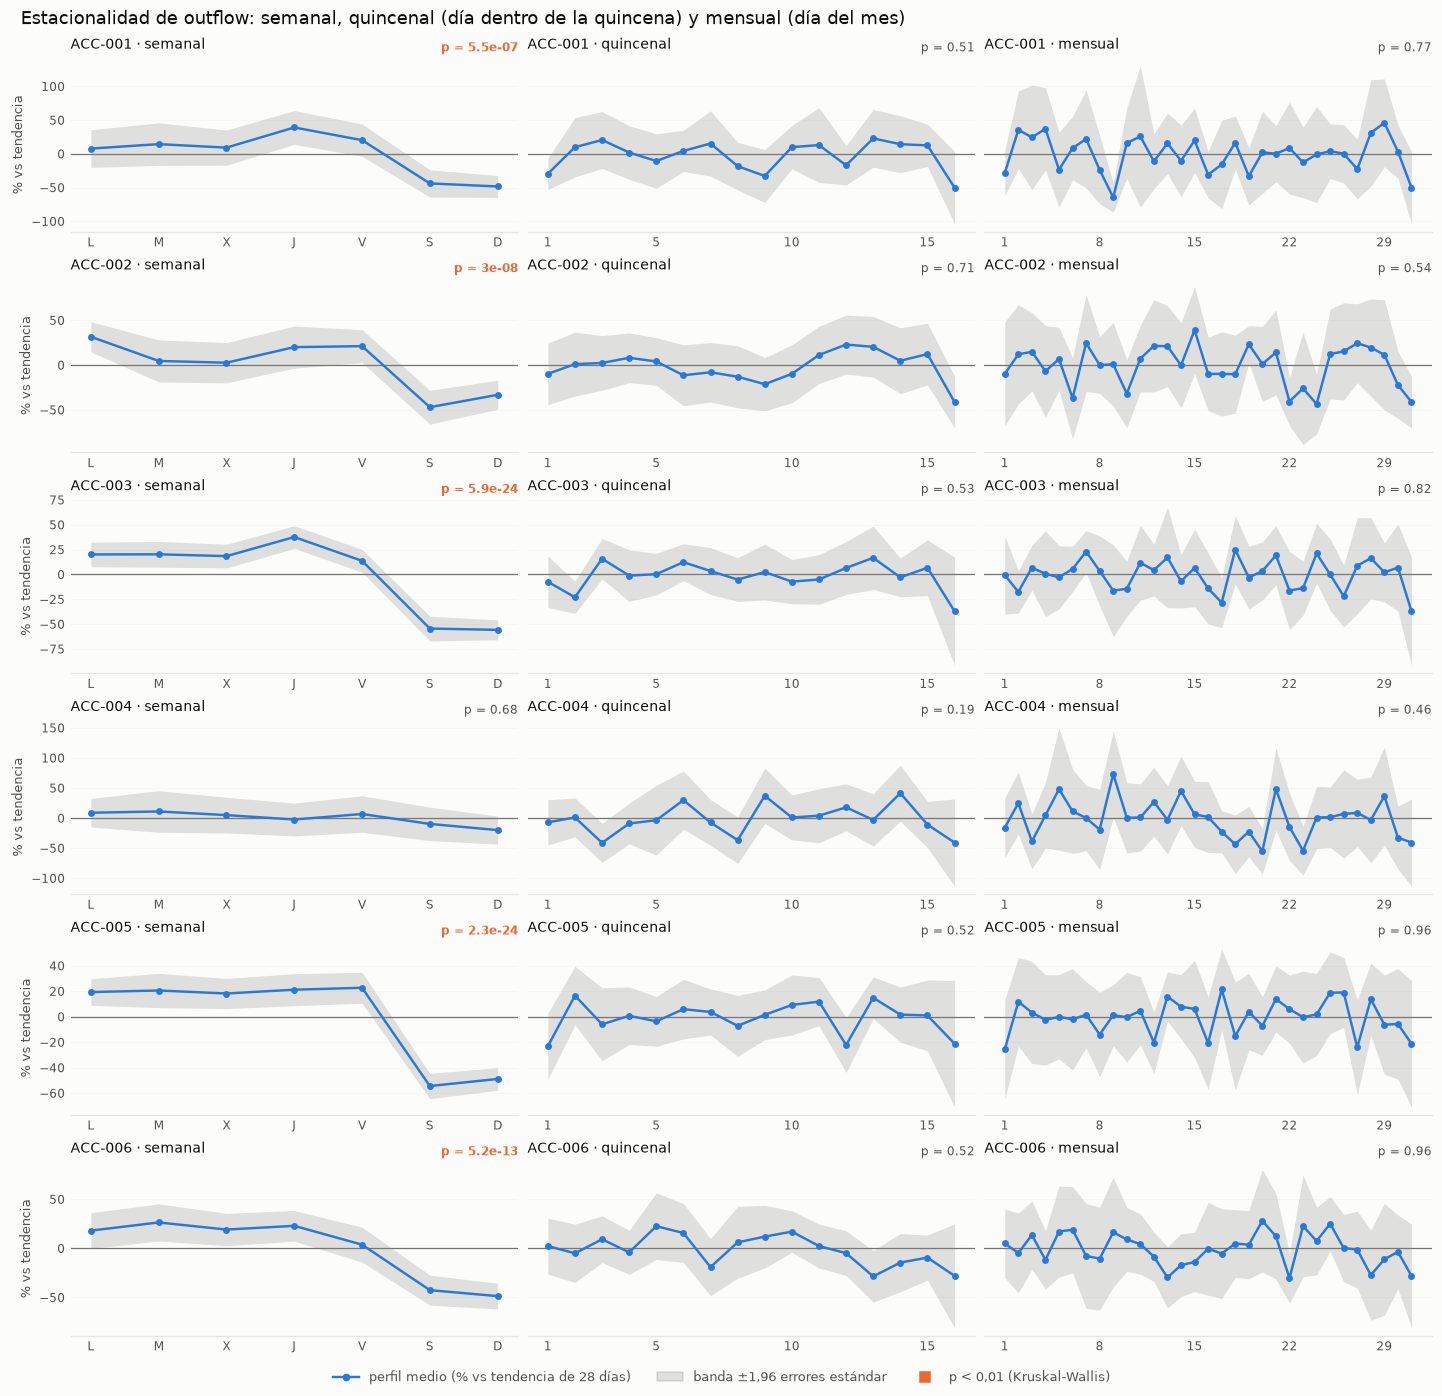

In [11]:
for serie in ("balance", "inflow", "outflow"):
    plots.fig_seasonality(panel, serie); plt.show()

In [12]:
pv = seasonality.cycle_pvalues(panel)
display(pv.map("{:.2g}".format).rename_axis(columns="p-valor (Kruskal-Wallis)"))
print(f"Ciclos quincenal y mensual con p < 0,01: {int((pv[['quincenal', 'mensual']] < 0.01).sum().sum())} de {pv[['quincenal', 'mensual']].size} pruebas "
      f"(por azar se esperaría ~{0.01 * pv[['quincenal', 'mensual']].size:.1f}).")

p-valor (Kruskal-Wallis)  semanal quincenal  mensual
account_id serie                                    
ACC-001    balance           0.61      0.94    0.079
           inflow          0.0013      0.96        1
           outflow        5.5e-07      0.51     0.77
ACC-002    balance           0.93      0.97        1
           inflow         9.3e-07      0.28     0.69
           outflow          3e-08      0.71     0.54
ACC-003    balance              1      0.12     0.75
           inflow         1.8e-22      0.62     0.82
           outflow        5.9e-24      0.53     0.82
ACC-004    balance           0.83      0.51  0.00069
           inflow         1.2e-05      0.34     0.65
           outflow           0.68      0.19     0.46
ACC-005    balance           0.94      0.99     0.98
           inflow         7.1e-18      0.67     0.86
           outflow        2.3e-24      0.52     0.96
ACC-006    balance           0.99      0.26    0.075
           inflow           7e-13      0.41     0.11
           outflow        5.2e-13      0.52     0.96

Ciclos quincenal y mensual con p < 0,01: 1 de 36 pruebas (por azar se esperaría ~0.4).


**Lectura.**

- **Semanal: es el único ciclo con señal clara, y solo en entradas y salidas.** El patrón es significativo (p < 0,01) en 11 de las 12 series de flujos; la excepción es el egreso de ACC-004 (p = 0,68). En el egreso, el fin de semana cae entre ~33% y ~55% respecto de la tendencia.
- **El saldo no tiene patrón semanal** (p entre 0,6 y 1,0 en las 6 cuentas): el efecto semanal de entradas y salidas se cancela en el neto y el saldo es su acumulado.
- **Quincenal: sin patrón.** Ninguna serie llega a p < 0,01 (el menor es 0,12, en el saldo de ACC-003) y la banda cubre el 0 en casi todas las posiciones. No se ve un efecto de día de pago.
- **Mensual: un único caso aislado.** El saldo de ACC-004 baja ~5% alrededor de los días 12 a 17 del mes (p = 0,0007). Es 1 de 36 pruebas quincenales y mensuales, cuando por azar se esperaría ~0,4, y coincide con la cuenta donde el notebook de diagnóstico ya encontró el componente de ~30 días más fuerte. Con ~9 observaciones por día es una pista, no una conclusión. Los saldos de ACC-001 y ACC-006 muestran ondulaciones suaves (p ≈ 0,08) que no alcanzan significancia.

**Qué esperar al lanzar ADF y el ACF/PACF:** el saldo se ve como una tendencia sin estacionalidad, así que lo esperable es que no sea estacionario en nivel; las entradas y salidas sí llevan un patrón semanal que hay que tratar (dummies de día de semana o un ETS estacional), y no hay ciclo quincenal ni mensual que modelar, con la excepción a vigilar de ACC-004.

#### D4b-2 · ACF / PACF: ¿hay que diferenciar? ¿dónde está la estacionalidad?

El test de día de semana dice **si** hay estacionalidad; el ACF/PACF dice **cómo se comporta** y cómo tratar el nivel. Se decide en dos pasos:

1. **Diferenciación (`d`).** Se diferencia solo si ADF no rechaza raíz unitaria **y** la diferencia no queda sobrediferenciada (ACF(1) de la diferencia por debajo de -0,25; diferenciar algo que no lo pedía da cerca de -0,5). KPSS se reporta como contraste.
2. **Estacionalidad.** Sobre la serie ya estacionaria (diferencia si `d = 1`; si no, el nivel menos la tendencia MSTL) se buscan picos en los rezagos 7, 14, 21 y 28. Solo se diferenciaría en el rezago 7 (`D = 1`) si el ACF estacional se mantiene alto **y** esa diferencia lo elimina; si lo deja cerca de -0,5, el patrón es determinístico y se modela con dummies, no con diferencias.

Se usa el panel ya limpio de F1. Sobre el crudo hay que enmascarar antes las lecturas corruptas, porque distorsionan el ACF (ver la sección 11 de `data_quality_diagnostics.ipynb`).

In [13]:
diff_t, seas_t, stationary = seasonality.acf_pacf_report(panel)
display(diff_t.rename(columns={
    "adf_p": "ADF p (nivel)", "kpss_p": "KPSS p (nivel)", "acf1_dif": "ACF(1) de la diferencia",
    "sobrediferenciada": "¿sobrediferenciada?", "kpss_confirma": "KPSS confirma"}).round(3))

ADF p (nivel)  KPSS p (nivel)  ACF(1) de la diferencia  ¿sobrediferenciada?  d  KPSS confirma
account_id serie                                                                                                 
ACC-001    balance           0.21            0.10                    -0.05                False  1          False
           inflow            0.00            0.10                    -0.47                 True  0           True
           outflow           0.00            0.10                    -0.42                 True  0           True
ACC-002    balance           0.98            0.01                    -0.05                False  1           True
           inflow            0.12            0.01                    -0.52                 True  0          False
           outflow           0.00            0.01                    -0.49                 True  0          False
ACC-003    balance           0.71            0.01                    -0.00                False  1           True
           inflow            0.09            0.01                    -0.27                 True  0          False
           outflow           0.09            0.01                    -0.27                 True  0          False
ACC-004    balance           0.07            0.01                     0.02                False  1           True
           inflow            0.00            0.01                    -0.48                 True  0          False
           outflow           0.00            0.01                    -0.49                 True  0          False
ACC-005    balance           0.96            0.01                    -0.13                False  1           True
           inflow            0.37            0.01                    -0.41                 True  0          False
           outflow           0.62            0.01                    -0.41                 True  0          False
ACC-006    balance           0.71            0.01                    -0.05                False  1           True
           inflow            0.31            0.01                    -0.45                 True  0          False
           outflow           0.35            0.01                    -0.38                 True  0          False

**Lectura.**

- **Saldo: se diferencia una vez (`d = 1`) en las 6 cuentas.** ADF no rechaza raíz unitaria (p de 0,07 a 0,98) y KPSS lo confirma en 5 de 6 (ACC-001 es la excepción, p = 0,10). La primera diferencia queda como ruido blanco (ACF(1) entre -0,13 y +0,02): el saldo se comporta como un **paseo aleatorio con deriva**.
- **Entradas y salidas: no se diferencian (`d = 0`) en ninguna de las 12 series.** Diferenciarlas las sobrediferencia (ACF(1) de la diferencia de -0,27 a -0,52, cerca del -0,5 teórico). KPSS rechaza estacionariedad en nivel en 10 de las 12, es decir, derivan lentamente; eso se resuelve quitándoles la tendencia (MSTL), no diferenciando.
- **Casos límite:** las entradas y salidas de ACC-003 (ADF p = 0,09; ACF(1) de la diferencia = -0,27, apenas por debajo del umbral de -0,25) son las decisiones más justas.

**Antes del ACF/PACF: la tendencia del saldo**, con la descomposición STL nativa de statsmodels (observado / tendencia / estacional / residuo), una figura por cuenta.

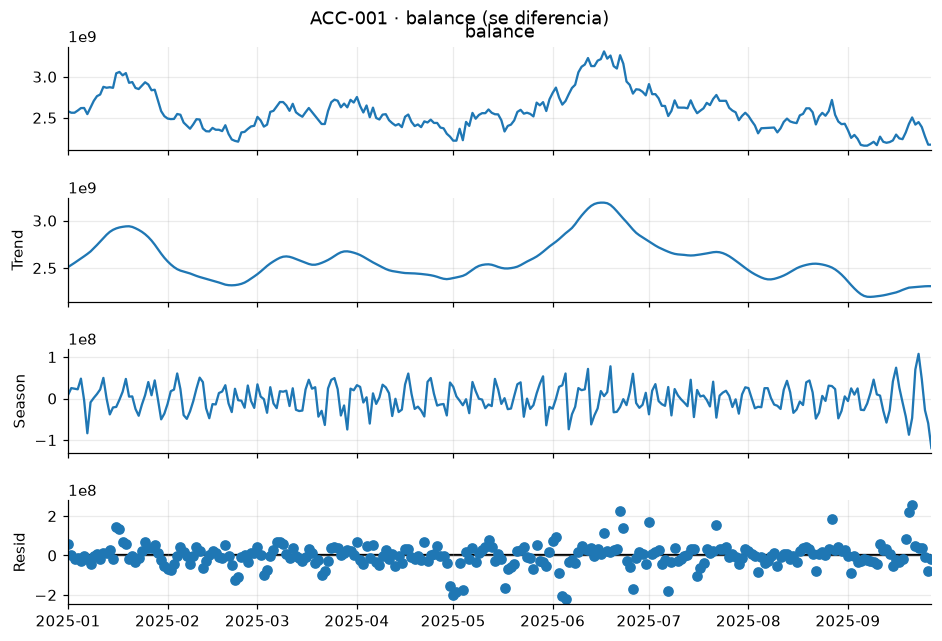

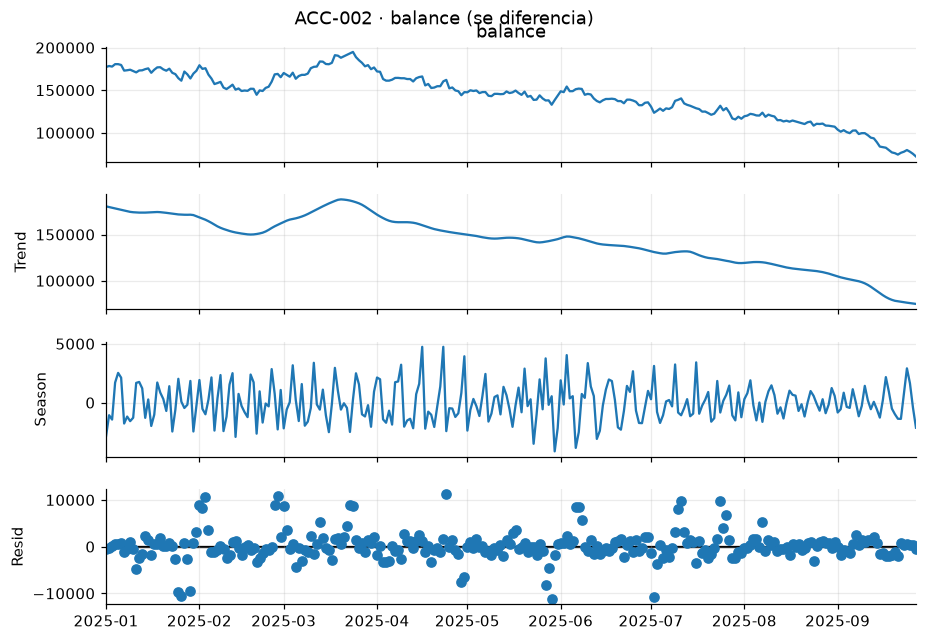

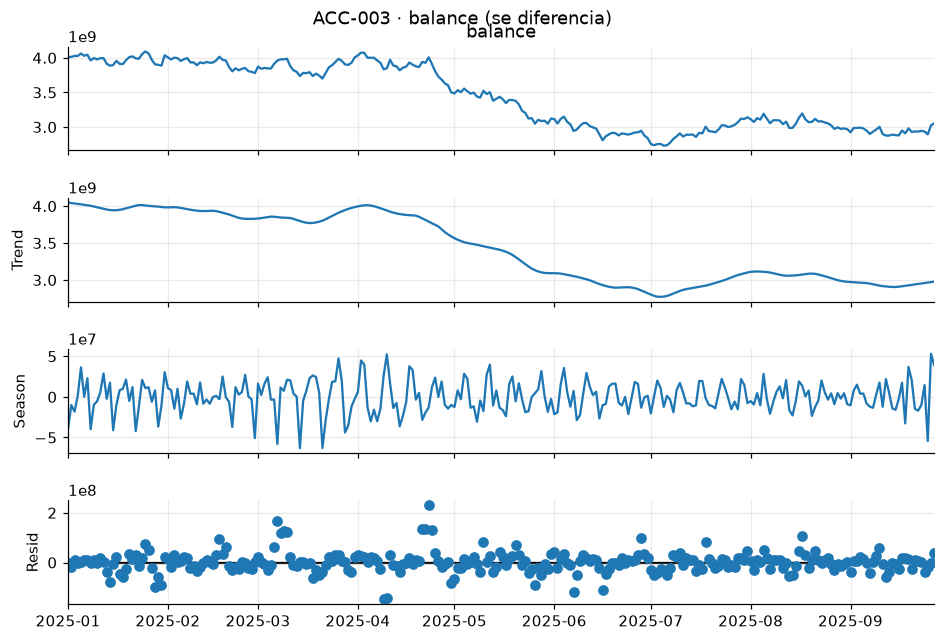

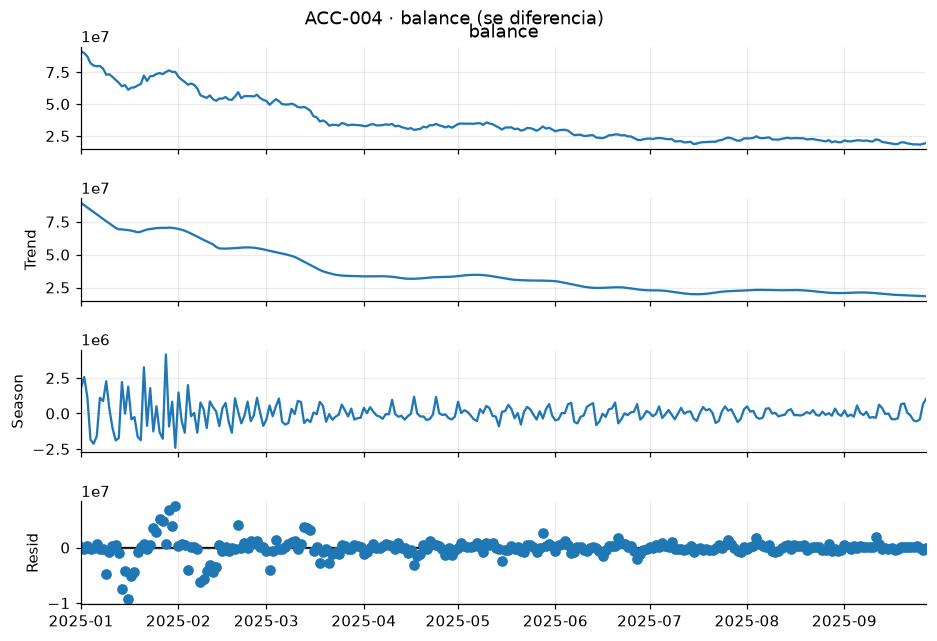

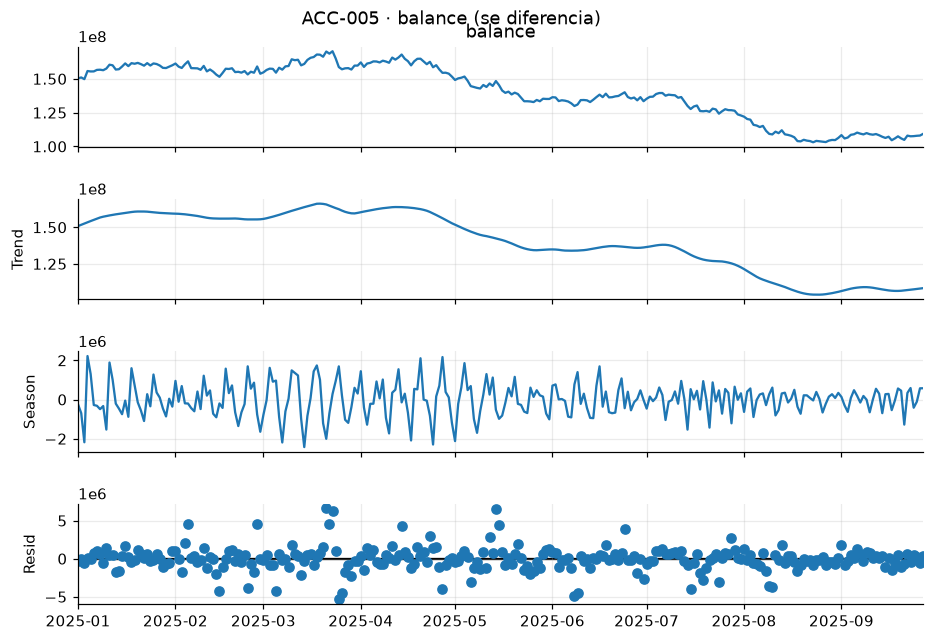

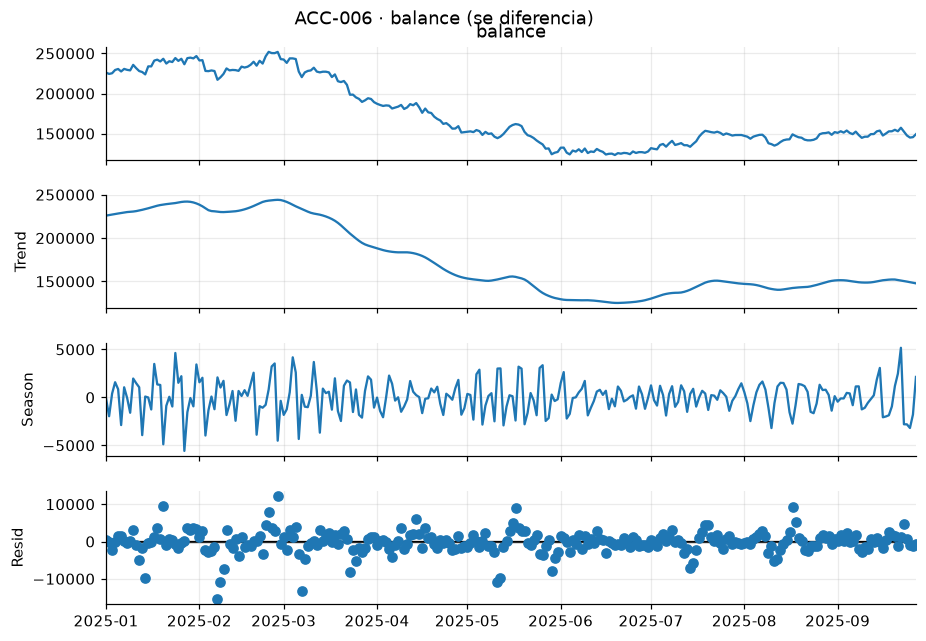

In [14]:
for acc in sorted(panel["account_id"].unique()):
    plots.fig_trend(panel, diff_t, acc); plt.show()

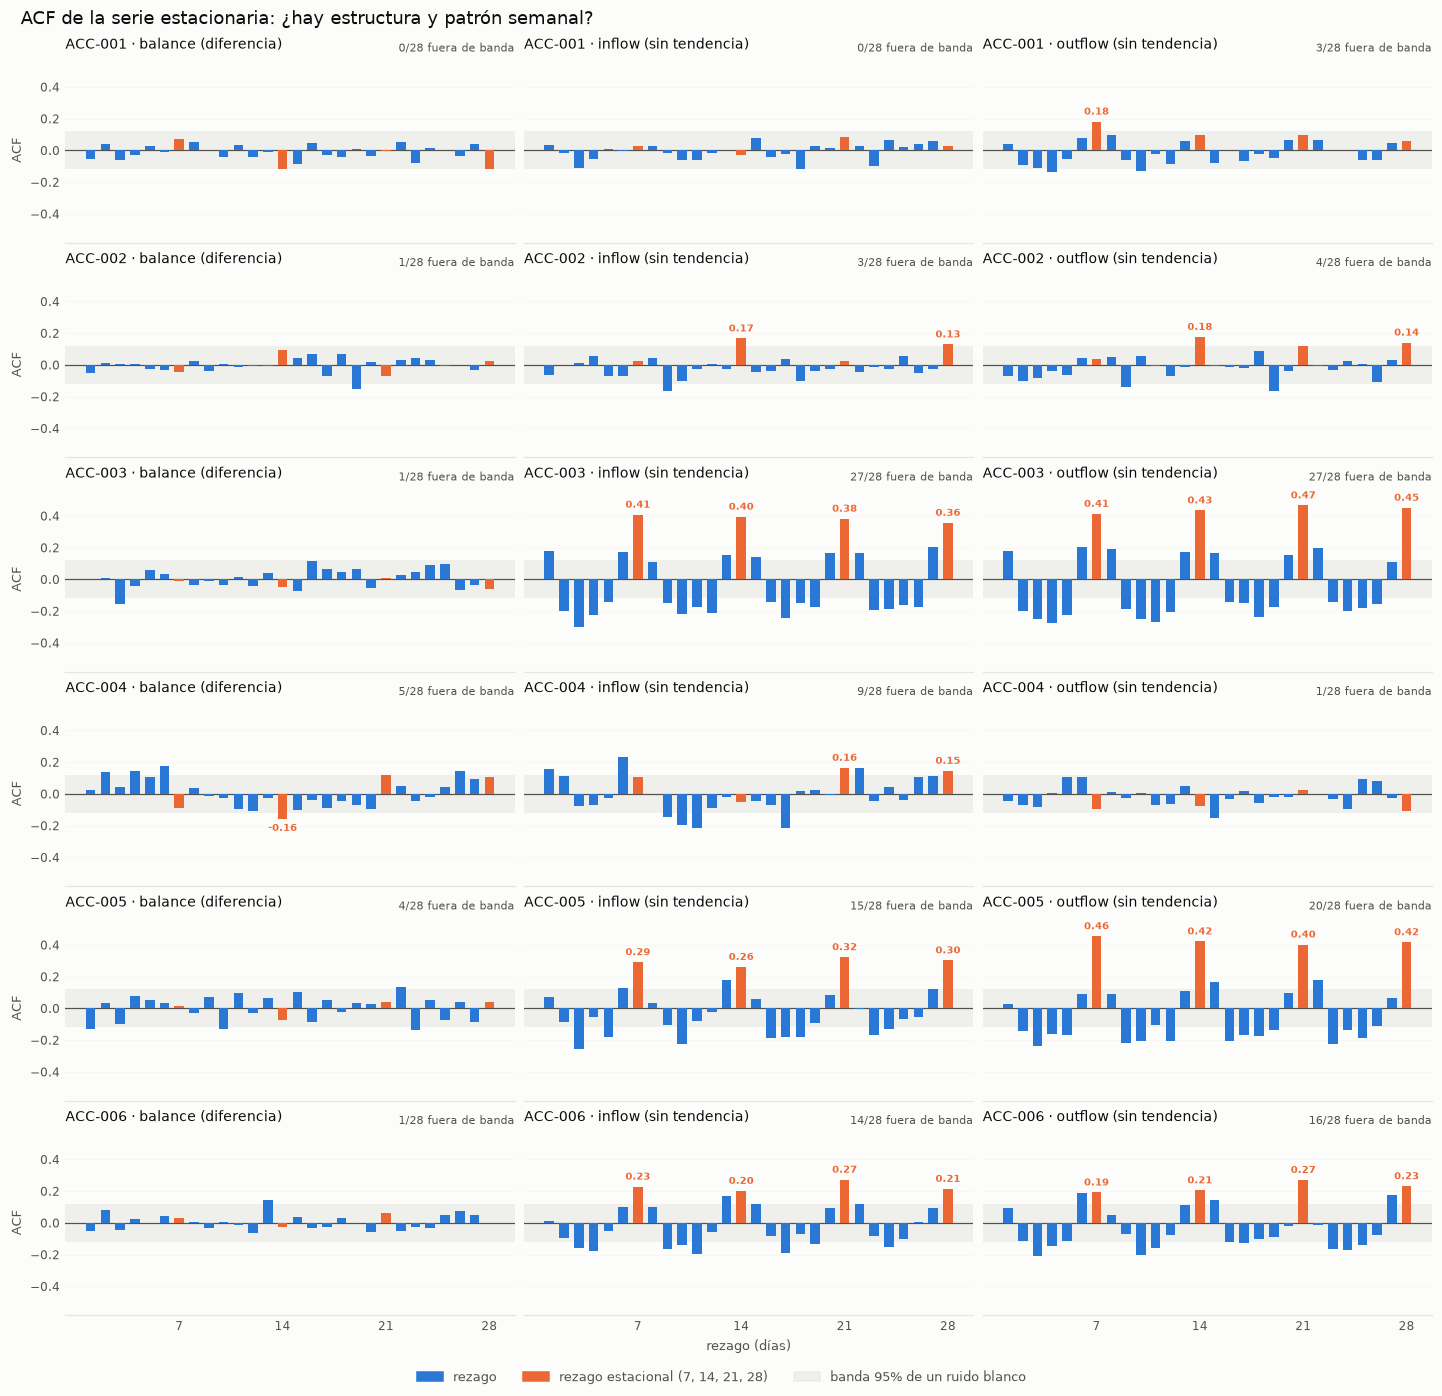

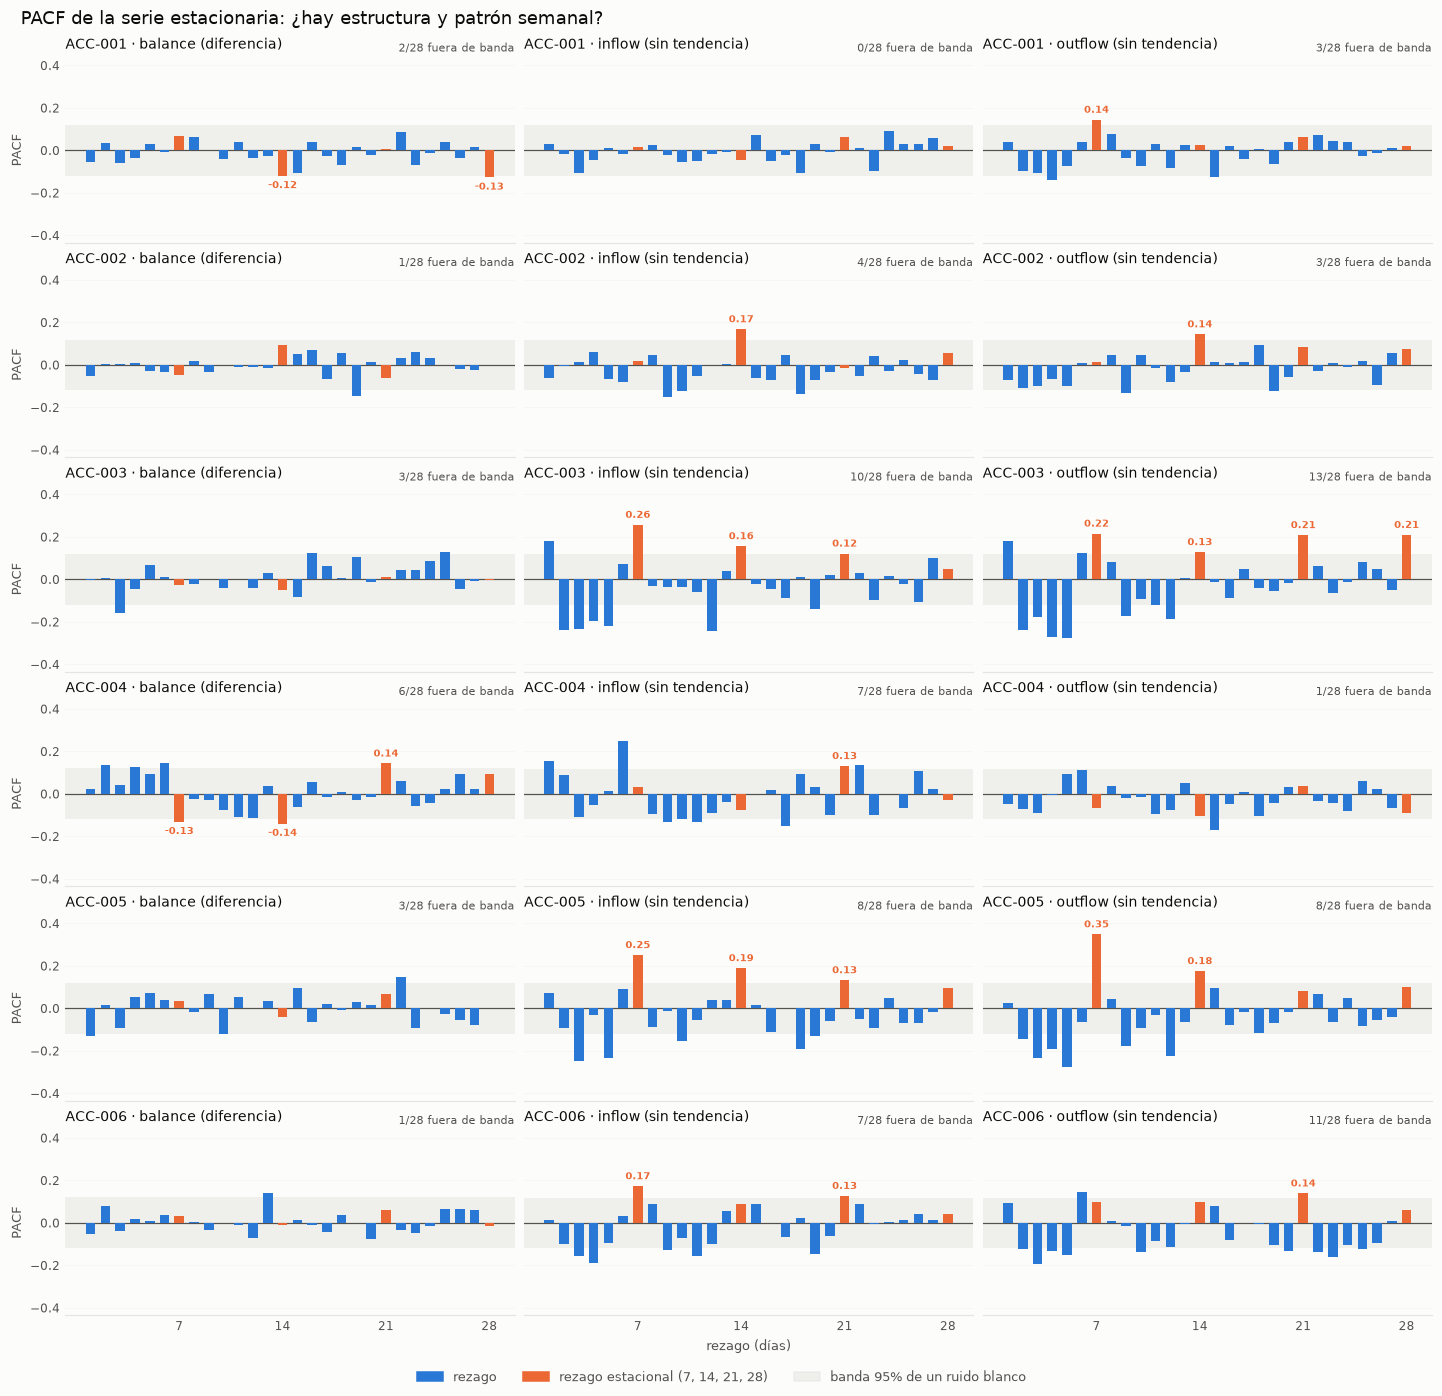

In [15]:
plots.fig_acf_pacf(stationary, diff_t, "acf"); plt.show()
plots.fig_acf_pacf(stationary, diff_t, "pacf"); plt.show()

**Lectura.** Las barras naranjas son los rezagos 7, 14, 21 y 28; las líneas punteadas, la banda de ruido blanco (±0,12).

- **Saldo (diferencia):** ACF y PACF dentro de la banda en casi todos los rezagos y sin picos estacionales: ni estructura AR/MA ni patrón semanal. La excepción es **ACC-004**, que conserva algo de autocorrelación (Ljung-Box p = 0,001).
- **Entradas y salidas de ACC-003, ACC-005 y ACC-006:** el ACF es un **"peine"**: picos en 7, 14, 21 y 28 con valores negativos entre ellos. Los picos casi no decaen (ACC-003 inflow: 0,41 / 0,40 / 0,38; ACC-005 outflow: 0,46 / 0,42 / 0,40), que es la firma de un **patrón semanal estable y determinístico** y no de una raíz unitaria estacional.
- El PACF es significativo en el rezago 7 en casi todas ellas, pero no es un corte limpio: también lo son algunos rezagos cortos, como es normal cuando el efecto de día de semana da forma a toda la semana.

In [16]:
display(seas_t.rename(columns={
    "acf_7": "ACF(7)", "pacf_7": "PACF(7)", "acf_14": "ACF(14)", "acf_21": "ACF(21)", "pico_7": "pico en 7",
    "picos_estacionales": "picos estacionales (de 4)", "ljung_box_p7": "Ljung-Box p (rezago 7)",
    "acf_7_tras_dif_7": "ACF(7) tras dif. en 7", "semanal": "¿semanal?"}).round(3))

d  ACF(7)  PACF(7)  ACF(14)  ACF(21)  pico en 7  picos estacionales (de 4)  Ljung-Box p (rezago 7)  ACF(7) tras dif. en 7  ¿semanal?  D
account_id serie                                                                                                                                           
ACC-001    balance  1    0.07     0.07    -0.12    -0.00       0.06                          0                    0.76                  -0.38      False  0
           inflow   0    0.03     0.02    -0.03     0.09       0.02                          0                    0.71                  -0.46      False  0
           outflow  0    0.18     0.14     0.10     0.10       0.17                          2                    0.00                  -0.44       True  0
ACC-002    balance  1   -0.05    -0.05     0.10    -0.07      -0.03                          0                    0.97                  -0.56      False  0
           inflow   0    0.03     0.02     0.17     0.02       0.09                          2                    0.65                  -0.57      False  0
           outflow  0    0.04     0.01     0.18     0.12       0.06                          3                    0.28                  -0.56      False  0
ACC-003    balance  1   -0.01    -0.03    -0.05     0.01      -0.02                          0                    0.28                  -0.48      False  0
           inflow   0    0.41     0.26     0.40     0.38       0.41                          4                    0.00                  -0.49       True  0
           outflow  0    0.41     0.22     0.43     0.47       0.42                          4                    0.00                  -0.52       True  0
ACC-004    balance  1   -0.09    -0.13    -0.16     0.12      -0.17                          1                    0.00                  -0.46      False  0
           inflow   0    0.11     0.03    -0.05     0.16       0.09                          1                    0.00                  -0.40      False  0
           outflow  0   -0.09    -0.07    -0.08     0.02      -0.14                          0                    0.09                  -0.49      False  0
ACC-005    balance  1    0.01     0.03    -0.07     0.04      -0.02                          0                    0.18                  -0.45      False  0
           inflow   0    0.29     0.25     0.26     0.32       0.32                          4                    0.00                  -0.49       True  0
           outflow  0    0.46     0.35     0.42     0.40       0.51                          4                    0.00                  -0.47       True  0
ACC-006    balance  1    0.03     0.03    -0.03     0.06       0.03                          0                    0.76                  -0.46      False  0
           inflow   0    0.23     0.17     0.20     0.27       0.23                          4                    0.00                  -0.48       True  0
           outflow  0    0.19     0.10     0.20     0.27       0.18                          4                    0.00                  -0.50       True  0

**Conclusión.** Un pico semanal cuenta si el ACF en el rezago 7 sobresale de sus vecinos más que la banda y al menos dos de los cuatro rezagos estacionales sobresalen.

- **Estacionalidad semanal en 7 de las 12 series de flujos:** entradas y salidas de ACC-003, ACC-005 y ACC-006, más la salida de ACC-001 (más débil, pico de 0,17). **Ningún saldo la tiene**, ni tampoco la entrada de ACC-001, ACC-002 y ACC-004.
- **Sin diferenciación estacional (`D = 0`) en ninguna serie.** Diferenciar en el rezago 7 deja el ACF(7) entre -0,38 y -0,57 (sobrediferencia) y los picos de arriba no decaen: el patrón semanal se modela con **dummies de día de semana o un ETS estacional**, no se elimina con diferencias.
- **Recomendación por tipo de serie:** saldo = `d = 1` sin estacionalidad (paseo aleatorio con deriva); entradas/salidas = `d = 0`, `D = 0` y efecto de día de semana donde la tabla lo marca.

Esto explica lo que sale en D4c: como el saldo no tiene estructura más allá de la deriva, "el último saldo" es muy difícil de superar y forzar una estacionalidad semanal sobre el saldo no mejora nada. El ACF/PACF es un detector conservador: el test de día de semana de D4b marca 11 de las 12 series de flujos y el ACF/PACF confirma las 7 más fuertes, mostrando además cómo es el patrón.

### D4c · Validación con `TimeSeriesSplit` y un forecast ETS

`TimeSeriesSplit` (scikit-learn) hace **ventana expansiva**: cada corte entrena con todo el pasado hasta un origen y prueba en el bloque de 14 días siguiente. Los bloques de prueba no se solapan y nunca preceden al entrenamiento. Se compara, contra el saldo real limpio:

- `squad_sin_limpiar` (la base) y `squad_limpio`: media de los últimos 14 (filas / días).
- `ultimo_saldo`: el saldo del origen sin cambios.
- `ets_nivel`: ETS del saldo con tendencia amortiguada, **sin** estacionalidad.
- `ets_nivel_semanal`: lo mismo con estacionalidad semanal **forzada**.
- `ets_flujos`: ETS de `inflow` y `outflow` por separado, con estacionalidad semanal solo si el test la identifica en el **entrenamiento** de ese corte.

Las razones son MAE del bloque sobre el MAE de `squad_sin_limpiar` (menor que 1 = mejor).

In [17]:
detail, info = tscv.cv_level_forecasts(panel, squad["balances"])
S = tscv.cv_summary(detail)

# cómo quedó el split: ventana expansiva, un bloque de prueba de 14 días por corte
all_days = pd.DatetimeIndex(sorted(panel["date"].unique()))
folds = detail.groupby("fold").agg(origen=("origen", "first"), prueba_desde=("date", "min"), prueba_hasta=("date", "max"))
folds.insert(1, "días de entrenamiento", [int((all_days <= o).sum()) for o in folds["origen"]])
display(folds)

print("Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):")
display(S["global"])
print("Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?")
display(S["por_corte"])
print("Por cuenta (razón vs squad sin limpiar):")
display(S["por_cuenta"]["razon_vs_base"].unstack("model")[list(tscv.MODELS)])
print("warnings de convergencia de los ETS (contados, no silenciados):", info["n_warnings"])

,origen,días de entrenamiento,prueba_desde,prueba_hasta
fold,,,,
1,2025-07-19,200,2025-07-20,2025-08-02
2,2025-08-02,214,2025-08-03,2025-08-16
3,2025-08-16,228,2025-08-17,2025-08-30
4,2025-08-30,242,2025-08-31,2025-09-13
5,2025-09-13,256,2025-09-14,2025-09-27


Global (razón media entre cuentas vs squad sin limpiar; <1 = mejor):


,razon_media_vs_base,cuentas_que_mejoran_a_base
model,,
squad_sin_limpiar,1.00,0
squad_limpio,0.81,5
ultimo_saldo,0.55,6
ets_nivel,0.57,6
ets_nivel_semanal,0.57,6
ets_flujos,0.62,5


Por corte (razón media entre cuentas): ¿el resultado es estable en el tiempo?


model,origen,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
fold,,,,,,,
1,2025-07-19,1.00,0.90,0.60,0.63,0.58,0.87
2,2025-08-02,1.00,1.00,0.60,0.61,0.66,0.63
3,2025-08-16,1.00,0.92,0.84,0.83,0.87,1.03
4,2025-08-30,1.00,0.87,0.66,0.75,0.74,0.95
5,2025-09-13,1.00,0.87,0.94,0.95,0.92,1.03


Por cuenta (razón vs squad sin limpiar):


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos
account_id,,,,,,
ACC-001,1.00,0.62,0.43,0.43,0.43,0.44
ACC-002,1.00,0.92,0.56,0.56,0.57,0.25
ACC-003,1.00,0.96,0.76,0.76,0.77,0.96
ACC-004,1.00,0.32,0.30,0.32,0.32,0.41
ACC-005,1.00,0.97,0.52,0.51,0.50,0.67
ACC-006,1.00,1.06,0.70,0.82,0.83,1.00


warnings de convergencia de los ETS (contados, no silenciados): {'squad_sin_limpiar': 0, 'squad_limpio': 0, 'ultimo_saldo': 0, 'ets_nivel': 0, 'ets_nivel_semanal': 0, 'ets_flujos': 0}


**Lectura.**

- **El split:** 5 cortes con ventana expansiva. El entrenamiento crece de 200 a 256 días y las pruebas cubren del 20-jul al 27-sep, en bloques de 14 días.
- **Todos los modelos nuevos le ganan al squad sobre datos sin limpiar:** error 38–45% menor (razones 0,55–0,62). Solo limpiar los datos ya baja el error de la media móvil un 19% (0,81), y mejora en 5 de 6 cuentas (ACC-006 empeora: 1,06).
- **La estacionalidad semanal no ayuda al saldo, como anticipaba D4b:** `ets_nivel_semanal` (0,57) queda igual que `ets_nivel` (0,57). Y el ETS con tendencia **no le gana al "último saldo"** (0,57 frente a 0,55).
- **`ets_flujos` es desigual:** es el mejor de todos en ACC-002 (0,25 frente a 0,56 del ETS de nivel), pero no le gana al squad en ACC-003 (0,96) ni en ACC-006 (1,00). En promedio (0,62) queda peor que el ETS del saldo. Identificó la semana en las entradas y salidas de casi todos los cortes (salvo el egreso de ACC-004), coherente con D4b.
- **La ventaja se achica con el tiempo:** en el último corte (origen 13-sep) todos quedan entre 0,87 y 1,03, con `ultimo_saldo` en 0,94, `ets_nivel` en 0,95 y `ets_flujos` en 1,03.

**Conclusión honesta:** la estacionalidad semanal se identifica con claridad, pero **no sirve para pronosticar el nivel del saldo a 14 días**. Casi toda la mejora frente al squad la logra ya "el último saldo", que no usa estacionalidad ni tendencia: viene de no promediar niveles viejos ni datos corruptos. Con 5 cortes × 14 días y 6 cuentas, la evidencia es corta: las diferencias entre `ultimo_saldo` y los ETS son un empate técnico. El valor de la estacionalidad semanal, si lo hay, estaría en los flujos diarios, que esta validación no mide.

### D4d · XGBoost con rezagos: ¿sobreestima, subestima o queda balanceado (±15%)?

Un modelo de otra familia (árboles con gradiente), validado **con los mismos cortes de `TimeSeriesSplit`** de D4c para que la comparación sea justa.

- **Un solo modelo global** para las 6 cuentas. Todo se normaliza por el egreso medio de 28 días de cada cuenta (*días de egreso*), así COP, MXN y USD son comparables.
- **Estrategia directa:** el objetivo es el cambio del saldo a *h* días, `(saldo[t+h] − saldo[t]) / escala[t]`, con *h* = 1…14 como variable. El pronóstico del saldo es `saldo[t] + ŷ · escala[t]`.
- **Variables (en *t*, solo pasado):** rezagos 0–6 del flujo neto, entradas y salidas en los rezagos 0 y 7, medias y desviación móviles del neto, cobertura en días, día de la semana de origen y de destino, y tipo de cuenta.
- **Sin fuga:** en cada corte el modelo solo entrena con objetivos que caen dentro del entrenamiento (un test verifica que alterar todo lo posterior al origen no cambia el pronóstico). Los hiperparámetros son fijos y modestos, **no se afinan sobre los cortes de prueba**.

**Cómo se lee la tabla.** Con `rel = (pronóstico − real) / real`: **sobreestima** si `rel > +15%` (el saldo real es menor al esperado: riesgo de faltante), **subestima** si `rel < −15%` (se movería dinero de más) y **balanceado** en el resto. MAPE = media de |rel|; sMAPE = media de 2|F−A|/(|F|+|A|).

**`MAE (días de egreso)`** = `|pronóstico − real| / escala`, con `escala` = egreso medio de los últimos 28 días de esa cuenta al origen del pronóstico (la misma normalización de la *estrategia directa*, arriba). No es un MAE en pesos/dólares — eso no se puede promediar entre COP, MXN y USD sin que la cuenta de saldo más grande domine el número global. Al dividir por el gasto diario típico de cada cuenta, el error queda en una unidad común: "días de egreso que ese error representa". Ej.: MAE = 1,4 significa que, en promedio, el pronóstico se equivoca por el equivalente a 1,4 días de lo que esa cuenta gasta normalmente.

In [18]:
from src import ml_forecast

detail_x = ml_forecast.cv_xgb(panel)                          # mismos cortes que D4c
detail_all = pd.concat([detail, detail_x], ignore_index=True)
order = list(tscv.MODELS) + ["xgboost"]

print("Todas las cuentas juntas, banda ±15%:")
display(ml_forecast.error_table(detail_all, panel).loc[order])
print("La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):")
display(ml_forecast.error_table(detail_all, panel, band=0.05).loc[order].iloc[:, :7])

Todas las cuentas juntas, banda ±15%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+15%),balanceado % (±15%),subestima % (<-15%),n
model,,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,9.76,86.43,3.81,420
squad_limpio,2.02,6.31,6.07,3.16,7.14,92.86,0.00,420
ultimo_saldo,1.40,4.36,4.26,1.56,3.10,96.90,0.00,420
ets_nivel,1.45,4.46,4.36,1.60,3.10,96.90,0.00,420
ets_nivel_semanal,1.46,4.50,4.39,1.88,3.33,96.67,0.00,420
ets_flujos,1.53,4.49,4.50,0.17,0.95,97.38,1.67,420
xgboost,1.36,4.18,4.17,-0.10,2.14,96.67,1.19,420


La misma tabla con banda ±5% (la de ±15% es muy holgada para un saldo a 14 días o menos):


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+5%),balanceado % (±5%),subestima % (<-5%)
model,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,34.76,43.81,21.43
squad_limpio,2.02,6.31,6.07,3.16,36.67,50.00,13.33
ultimo_saldo,1.40,4.36,4.26,1.56,19.76,70.24,10.00
ets_nivel,1.45,4.46,4.36,1.60,22.38,66.90,10.71
ets_nivel_semanal,1.46,4.50,4.39,1.88,24.76,66.43,8.81
ets_flujos,1.53,4.49,4.50,0.17,18.10,67.14,14.76
xgboost,1.36,4.18,4.17,-0.10,14.52,68.81,16.67


In [19]:
by_acc = ml_forecast.error_table(detail_all, panel, by=("account_id", "model"))
for col in ["MAPE %", "sMAPE %", "balanceado % (±15%)", "sesgo % (+ = sobreestima)"]:
    print(col)
    display(by_acc[col].unstack("model")[order])
w, n = ml_forecast.block_wins(detail_all, "xgboost", "ultimo_saldo")
print(f"XGBoost tiene menor MAE que el último saldo en {w} de {n} bloques (corte × cuenta).")
display(ml_forecast.feature_importance(panel).rename("importancia (ganancia)").to_frame())

MAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.21,7.22,4.94,4.97,5.01,5.05,4.99
ACC-002,12.21,11.22,7.02,6.97,7.07,2.98,5.74
ACC-003,2.91,2.81,2.22,2.22,2.22,2.78,2.61
ACC-004,21.53,6.55,6.01,6.31,6.43,8.13,5.94
ACC-005,6.41,6.25,3.43,3.31,3.29,4.35,3.31
ACC-006,3.61,3.82,2.53,2.96,2.99,3.64,2.46


sMAPE %


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,11.41,7.01,4.89,4.92,4.93,4.97,5.04
ACC-002,11.44,10.27,6.57,6.53,6.62,2.91,5.41
ACC-003,2.93,2.82,2.23,2.23,2.23,2.80,2.66
ACC-004,16.51,6.43,6.01,6.33,6.37,8.26,6.08
ACC-005,6.16,6.02,3.36,3.26,3.23,4.47,3.31
ACC-006,3.65,3.85,2.52,2.93,2.97,3.57,2.50


balanceado % (±15%)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,70.00,88.57,100.00,100.00,100.00,100.00,100.00
ACC-002,77.14,78.57,84.29,84.29,84.29,100.00,87.14
ACC-003,100.00,100.00,100.00,100.00,100.00,100.00,100.00
ACC-004,77.14,94.29,97.14,97.14,95.71,84.29,92.86
ACC-005,94.29,95.71,100.00,100.00,100.00,100.00,100.00
ACC-006,100.00,100.00,100.00,100.00,100.00,100.00,100.00


sesgo % (+ = sobreestima)


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost
account_id,,,,,,,
ACC-001,-1.55,2.96,1.02,1.05,1.76,1.62,-0.81
ACC-002,7.08,11.18,6.47,6.41,6.51,1.88,4.85
ACC-003,-0.42,-0.35,-0.35,-0.35,-0.30,-0.45,-1.56
ACC-004,17.11,1.94,0.11,0.07,1.02,-1.04,-1.91
ACC-005,4.87,4.68,1.86,1.60,1.60,-2.49,0.13
ACC-006,-1.70,-1.43,0.27,0.86,0.72,1.50,-1.29


XGBoost tiene menor MAE que el último saldo en 18 de 30 bloques (corte × cuenta).


,importancia (ganancia)
neto_media14,0.09
neto_std14,0.08
neto_media28,0.08
horizonte_h,0.08
cobertura_dias,0.06
es_reserva,0.06
entrada_lag7,0.05
neto_lag2,0.05
salida_lag0,0.05
salida_lag7,0.05


**Lectura.**

- **XGBoost tiene el menor error, pero por muy poco.** MAE de 1,36 días de egreso, MAPE de 4,18% y sMAPE de 4,17%, frente a 1,40 / 4,36 / 4,26 del "último saldo". Le gana en **18 de 30 bloques (60%)**: un empate técnico, no una ventaja.
- **Sobreestimación, subestimación y balance (banda ±15%).** El squad sobre datos sin limpiar queda balanceado el 86,4% de las veces: sobreestima el 9,8% y subestima el 3,8%, con un sesgo de +4,2% (en ACC-004, +17%). Limpiar los datos sube el balance a 92,9% y elimina la subestimación. XGBoost queda en 96,7% balanceado (2,1% sobreestima, 1,2% subestima) con el sesgo más neutro (−0,10%); el último saldo, en 96,9%.
- **La banda de ±15% es muy holgada** para un saldo a 14 días o menos: casi todo cae dentro (97%). Con ±5% las diferencias sí aparecen: 43,8% balanceado (squad sin limpiar) → 50,0% (limpio) → 70,2% (último saldo) y 68,8% (XGBoost). XGBoost sobreestima menos (14,5% frente a 19,8%) pero subestima más (16,7% frente a 10,0%): **cambia el tipo de error más que reducirlo**.
- **El error se concentra en ACC-002 y ACC-004:** son las únicas cuentas donde algún modelo queda por debajo del 100% balanceado a ±15%. En ACC-002 el mejor es `ets_flujos` (MAPE 2,98% frente a 5,74% de XGBoost); en las otras cuentas ningún modelo se separa del último saldo.
- **La importancia de variables está repartida** (la mayor no pasa de 9%: media y desviación móviles del neto, horizonte, cobertura), sin una variable dominante: es la firma de una señal débil. Los rezagos semanales de entradas y salidas aportan ~5% cada uno.

**Qué significa para rebalancear.** Sobreestimar el saldo es lo peligroso (riesgo de faltante) y subestimarlo cuesta movimientos de más. Lo que sí se ve con claridad es que el squad sobre datos sin limpiar sobreestima de forma sistemática; cambiar el modelo por XGBoost casi no mejora al "último saldo". Por eso **el valor no está en un mejor pronóstico puntual, sino en la distribución (cuantiles) y en la regla de decisión** (B, C y D). Además, XGBoost entrega un punto: para alimentar la política de cuantil haría falta un modelo de cuantiles o un bootstrap de sus residuos. Límites: 5 cortes × 14 días × 6 cuentas (420 pronósticos correlacionados entre sí) sobre los últimos 70 días.

### D4e · El reto: un modelo por cuenta (no uno global), afinado — ¿mejora el MAPE?

D4d usa **un solo** XGBoost para las 6 cuentas juntas. La pregunta obvia: ¿un modelo dedicado por serie —con sus
propios hiperparámetros— hace mejor trabajo que uno genérico? Se prueba con LightGBM, misma mecánica de variables
y estrategia directa que D4d (`src/ml_forecast.py`), pero:

- **Un modelo por cuenta**, no pooled: `ml_forecast.cv_lgbm(panel, tuned_params=...)`.
- **Afinado con Optuna** (TPE, 30 pruebas por cuenta) — a diferencia de D4d, donde `cfg.XGB_PARAMS` está fijo
  *a propósito* ("no se afinan sobre los cortes de prueba"). Aquí sí se afina, pero sin tocar los cortes que se
  reportan: `ml_forecast.tune_lgbm_per_account` corre una CV interna que **termina antes de que arranque la CV
  externa** de D4c/D4d (día 200 de 270, `ml_forecast.outer_cv_first_test_start`). Ningún hiperparámetro pudo haber
  visto ni de refilón ninguno de los 5 cortes que se comparan abajo — hay un test (`test_tune_lgbm_never_sees_the_outer_test_folds`)
  que lo verifica alterando los datos desde ese día en adelante y comprobando que la elección no cambia.
- **Un control:** `ml_forecast.cv_lgbm_pooled` — LightGBM pooled, como XGBoost, con los parámetros por defecto
  **sin afinar**. Aísla si un resultado peor viene del *algoritmo* (LightGBM vs XGBoost) o de *partir los datos*
  en 6 modelos: aquí solo cambia el algoritmo, todo lo demás queda igual que D4d.

In [20]:
best_params, search = ml_forecast.tune_lgbm_per_account(panel)   # ~15-20 s: 30 pruebas de Optuna x 6 cuentas
print(f"Mejor MAE interno (normalizado, CV antes del día {ml_forecast.outer_cv_first_test_start(len(panel['date'].unique()))}) por cuenta:")
display(search.loc[search["elegido"]].set_index("account_id")[["mae_norm_interno", "n_estimators", "learning_rate", "num_leaves", "min_child_samples", "reg_lambda"]].round(4))

Mejor MAE interno (normalizado, CV antes del día 200) por cuenta:


,mae_norm_interno,n_estimators,learning_rate,num_leaves,min_child_samples,reg_lambda
account_id,,,,,,
ACC-001,2.72,54,0.01,20,17,7.85
ACC-002,1.86,186,0.04,30,38,2.68
ACC-003,1.22,115,0.02,3,18,2.85
ACC-004,1.30,384,0.09,14,39,2.06
ACC-005,0.88,320,0.05,14,28,20.17
ACC-006,1.68,57,0.01,22,40,4.73


Los parámetros que gana cada cuenta son distintos entre sí (número de hojas, tasa de aprendizaje, regularización):
Optuna no converge al mismo modelo para las 6, lo que es razonable — no comparten escala ni dinámica.

In [21]:
detail_l = ml_forecast.cv_lgbm(panel, tuned_params=best_params)         # por cuenta, afinado
detail_pooled = ml_forecast.cv_lgbm_pooled(panel)                       # control: pooled, sin afinar
detail_all = pd.concat([detail_all, detail_pooled, detail_l], ignore_index=True)
order = order + ["lightgbm_pooled", "lightgbm"]

print("Todas las cuentas juntas, banda ±15%:")
display(ml_forecast.error_table(detail_all, panel).loc[order])
print("La misma tabla con banda ±5%:")
display(ml_forecast.error_table(detail_all, panel, band=0.05).loc[order].iloc[:, :7])

Todas las cuentas juntas, banda ±15%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+15%),balanceado % (±15%),subestima % (<-15%),n
model,,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,9.76,86.43,3.81,420
squad_limpio,2.02,6.31,6.07,3.16,7.14,92.86,0.00,420
ultimo_saldo,1.40,4.36,4.26,1.56,3.10,96.90,0.00,420
ets_nivel,1.45,4.46,4.36,1.60,3.10,96.90,0.00,420
ets_nivel_semanal,1.46,4.50,4.39,1.88,3.33,96.67,0.00,420
ets_flujos,1.53,4.49,4.50,0.17,0.95,97.38,1.67,420
xgboost,1.36,4.18,4.17,-0.10,2.14,96.67,1.19,420
lightgbm_pooled,1.41,4.31,4.30,-0.12,2.14,96.67,1.19,420
lightgbm,1.38,4.28,4.27,-0.07,2.38,95.95,1.67,420


La misma tabla con banda ±5%:


,MAE (días de egreso),MAPE %,sMAPE %,sesgo % (+ = sobreestima),sobreestima % (>+5%),balanceado % (±5%),subestima % (<-5%)
model,,,,,,,
squad_sin_limpiar,2.93,9.64,8.68,4.23,34.76,43.81,21.43
squad_limpio,2.02,6.31,6.07,3.16,36.67,50.00,13.33
ultimo_saldo,1.40,4.36,4.26,1.56,19.76,70.24,10.00
ets_nivel,1.45,4.46,4.36,1.60,22.38,66.90,10.71
ets_nivel_semanal,1.46,4.50,4.39,1.88,24.76,66.43,8.81
ets_flujos,1.53,4.49,4.50,0.17,18.10,67.14,14.76
xgboost,1.36,4.18,4.17,-0.10,14.52,68.81,16.67
lightgbm_pooled,1.41,4.31,4.30,-0.12,14.76,67.86,17.38
lightgbm,1.38,4.28,4.27,-0.07,14.05,71.67,14.29


In [22]:
by_acc_e = ml_forecast.error_table(detail_all, panel, by=("account_id", "model"))
print("MAPE % por cuenta:")
display(by_acc_e["MAPE %"].unstack("model")[order])

for rival in ("ultimo_saldo", "xgboost"):
    for m in ("xgboost", "lightgbm_pooled", "lightgbm"):
        if m == rival:
            continue
        w, n = ml_forecast.block_wins(detail_all, m, rival)
        print(f"{m} le gana a {rival} en {w} de {n} bloques (corte × cuenta)")

MAPE % por cuenta:


model,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
account_id,,,,,,,,,
ACC-001,11.21,7.22,4.94,4.97,5.01,5.05,4.99,5.09,5.14
ACC-002,12.21,11.22,7.02,6.97,7.07,2.98,5.74,6.02,5.95
ACC-003,2.91,2.81,2.22,2.22,2.22,2.78,2.61,2.77,2.76
ACC-004,21.53,6.55,6.01,6.31,6.43,8.13,5.94,5.89,5.80
ACC-005,6.41,6.25,3.43,3.31,3.29,4.35,3.31,3.52,3.29
ACC-006,3.61,3.82,2.53,2.96,2.99,3.64,2.46,2.55,2.74


xgboost le gana a ultimo_saldo en 18 de 30 bloques (corte × cuenta)
lightgbm_pooled le gana a ultimo_saldo en 18 de 30 bloques (corte × cuenta)
lightgbm le gana a ultimo_saldo en 16 de 30 bloques (corte × cuenta)
lightgbm_pooled le gana a xgboost en 13 de 30 bloques (corte × cuenta)
lightgbm le gana a xgboost en 10 de 30 bloques (corte × cuenta)


**Lectura.**

- **No es el algoritmo.** `lightgbm_pooled` (mismo diseño que XGBoost: global, sin afinar) queda a MAPE 4,31%
  frente al 4,18% de XGBoost y le gana en 18 de 30 bloques a "último saldo" — igual que XGBoost. LightGBM y
  XGBoost, en igualdad de condiciones, empatan.
- **Sí es partir los datos.** El modelo por cuenta, incluso afinado, queda en MAPE 4,28% — mejor que un primer
  intento sin afinar (una grilla manual de 6 combos había dado 4,68%: Optuna cierra la mayor parte de esa
  brecha) pero **no supera a ningún modelo pooled**. Le gana a "último saldo" en solo 16 de 30 bloques (menos
  que los dos modelos pooled) y a XGBoost en apenas 10 de 30. Partir 270 días entre 6 modelos dedicados deja a
  cada uno con una fracción de los datos que el modelo pooled sí aprovecha, y ni una afinación honesta (sin fuga,
  verificada por test) alcanza a compensarlo con esta cantidad de historia.
- **El matiz que sí favorece al modelo por cuenta: el sesgo.** Es el más neutro de los tres (−0,07%, frente a
  −0,10% de XGBoost y −0,12% del pooled) y el que más veces cae "balanceado" en la banda estricta de ±5%
  (71,7%, por encima incluso de "último saldo", 70,2%). No es más preciso en promedio, pero es el más parejo:
  ni sobreestima ni subestima de forma sistemática en ninguna cuenta.
- **Conclusión honesta del reto:** con ~9 meses de historia, especializar el modelo por cuenta no mejora el
  MAPE frente al modelo global de D4d, aunque sí mejora frente a no afinar. El mensaje es el mismo de 2.3 y de
  D4d: en estos datos no hay una ganancia clara y consistente de ir a un modelo más complejo o más específico
  — el límite no es el algoritmo, es cuánta historia hay para entrenarlo.

### D4f · Pronóstico de los últimos 14 días del dataset, todos los modelos lado a lado

El último corte de `TimeSeriesSplit` (fold 5) prueba exactamente en los últimos 14 días del panel (20-jul a 27-sep... el bloque real es 14-sep a 27-sep). `detail_all` ya trae los 9 modelos de D4c/D4d/D4e sobre los mismos cortes, así que no hay que reentrenar nada: se filtra ese fold y se pivotea `forecast` por modelo, con `real` al lado para comparar a ojo.

In [23]:
last_fold = detail_all["fold"].max()
last14 = detail_all[detail_all["fold"] == last_fold]
print(f"Últimos 14 días del dataset: {last14['date'].min().date()} a {last14['date'].max().date()}\n")

for acc, g in last14.groupby("account_id"):
    ccy = panel.loc[panel["account_id"] == acc, "currency"].iloc[0]
    piv = g.pivot(index="date", columns="model", values="forecast")[order]
    piv.insert(0, "real", g.drop_duplicates("date").set_index("date")["real"])
    print(f"{acc} ({ccy}):")
    display(piv.round(0))


Últimos 14 días del dataset: 2025-09-14 a 2025-09-27

ACC-001 (COP):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"2,203,863,751.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,529,956.00","2,215,761,163.00","2,213,398,391.00","2,198,303,621.00","2,208,278,112.00","2,183,439,566.00"
2025-09-15,"2,224,037,969.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,522,208.00","2,219,441,525.00","2,215,817,488.00","2,200,305,791.00","2,206,045,776.00","2,184,980,286.00"
2025-09-16,"2,295,023,607.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,515,264.00","2,225,230,595.00","2,220,214,827.00","2,197,353,184.00","2,202,048,657.00","2,184,980,286.00"
2025-09-17,"2,248,485,030.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,509,038.00","2,231,866,910.00","2,227,274,560.00","2,193,879,786.00","2,200,915,143.00","2,186,751,828.00"
2025-09-18,"2,239,353,153.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,503,458.00","2,217,452,725.00","2,212,091,328.00","2,191,568,496.00","2,193,028,159.00","2,183,930,967.00"
2025-09-19,"2,320,368,937.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,498,456.00","2,195,221,395.00","2,188,913,985.00","2,186,874,109.00","2,187,960,315.00","2,182,390,248.00"
2025-09-20,"2,425,618,384.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,493,973.00","2,195,279,475.00","2,187,869,871.00","2,182,146,251.00","2,182,501,192.00","2,183,856,041.00"
2025-09-21,"2,503,939,161.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,489,954.00","2,214,547,451.00","2,205,833,779.00","2,176,408,452.00","2,173,845,331.00","2,183,856,041.00"
2025-09-22,"2,417,147,046.00","2,249,930,832.00","2,234,584,641.00","2,195,434,483.00","2,196,486,351.00","2,218,364,663.00","2,208,252,876.00","2,172,734,297.00","2,173,931,107.00","2,185,396,761.00"


ACC-002 (USD):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"89,003.00","102,120.00","100,218.00","93,442.00","93,473.00","93,443.00","92,180.00","92,769.00","93,297.00","93,752.00"
2025-09-15,"83,753.00","102,120.00","100,218.00","93,442.00","93,444.00","93,580.00","91,148.00","92,837.00","93,494.00","94,029.00"
2025-09-16,"83,148.00","102,120.00","100,218.00","93,442.00","93,417.00","93,683.00","90,081.00","92,700.00","93,318.00","94,122.00"
2025-09-17,"82,439.00","102,120.00","100,218.00","93,442.00","93,390.00","94,043.00","89,189.00","92,469.00","93,210.00","94,016.00"
2025-09-18,"79,623.00","102,120.00","100,218.00","93,442.00","93,363.00","92,912.00","86,896.00","92,250.00","92,671.00","92,964.00"
2025-09-19,"76,934.00","102,120.00","100,218.00","93,442.00","93,337.00","92,791.00","85,615.00","92,072.00","92,448.00","92,827.00"
2025-09-20,"76,042.00","102,120.00","100,218.00","93,442.00","93,312.00","93,439.00","85,104.00","91,888.00","91,994.00","92,238.00"
2025-09-21,"74,376.00","102,120.00","100,218.00","93,442.00","93,287.00","93,367.00","83,842.00","91,659.00","91,715.00","91,860.00"
2025-09-22,"76,492.00","102,120.00","100,218.00","93,442.00","93,262.00","93,519.00","82,809.00","91,555.00","91,910.00","91,783.00"


ACC-003 (COP):


...

model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"19,920,756.00","35,098,606.00","21,158,419.00","20,351,369.00","20,505,730.00","20,355,040.00","19,857,315.00","20,111,786.00","20,160,148.00","20,265,494.00"
2025-09-15,"19,490,143.00","35,098,606.00","21,158,419.00","20,351,369.00","20,403,699.00","20,284,455.00","19,872,438.00","20,115,191.00","20,117,580.00","20,167,176.00"
2025-09-16,"19,059,530.00","35,098,606.00","21,158,419.00","20,351,369.00","20,315,741.00","20,435,764.00","19,978,256.00","20,067,131.00","19,974,240.00","20,005,374.00"
2025-09-17,"18,628,916.00","35,098,606.00","21,158,419.00","20,351,369.00","20,239,916.00","20,532,664.00","20,250,099.00","19,985,727.00","19,952,196.00","19,691,739.00"
2025-09-18,"18,724,224.00","35,098,606.00","21,158,419.00","20,351,369.00","20,174,550.00","20,552,353.00","20,263,638.00","19,948,902.00","19,890,532.00","19,566,713.00"
2025-09-19,"19,984,222.00","35,098,606.00","21,158,419.00","20,351,369.00","20,118,200.00","20,488,043.00","20,257,371.00","19,864,758.00","19,885,203.00","19,440,984.00"
2025-09-20,"19,984,222.00","35,098,606.00","21,158,419.00","20,351,369.00","20,069,622.00","20,088,972.00","19,678,653.00","19,781,822.00","19,676,534.00","19,073,919.00"
2025-09-21,"19,166,926.00","35,098,606.00","21,158,419.00","20,351,369.00","20,027,745.00","19,914,377.00","19,184,598.00","19,678,771.00","19,574,302.00","19,054,274.00"
2025-09-22,"18,845,838.00","35,098,606.00","21,158,419.00","20,351,369.00","19,991,645.00","19,906,639.00","19,199,721.00","19,595,536.00","19,497,814.00","18,924,460.00"


ACC-005 (MXN):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"107,147,747.00","108,319,866.00","108,454,000.00","108,262,393.00","108,407,426.00","108,843,405.00","108,441,328.00","107,896,065.00","108,188,513.00","108,259,717.00"
2025-09-15,"106,285,095.00","108,319,866.00","108,454,000.00","108,262,393.00","108,414,014.00","108,700,092.00","108,118,015.00","107,904,959.00","108,289,004.00","108,954,641.00"
2025-09-16,"107,196,086.00","108,319,866.00","108,454,000.00","108,262,393.00","108,420,079.00","108,533,446.00","107,770,232.00","107,782,722.00","108,125,523.00","109,260,321.00"
2025-09-17,"104,593,997.00","108,319,866.00","108,454,000.00","108,262,393.00","108,425,662.00","108,605,253.00","107,656,388.00","107,637,852.00","108,082,904.00","108,977,882.00"
2025-09-18,"105,906,087.00","108,319,866.00","108,454,000.00","108,262,393.00","108,430,803.00","108,198,718.00","107,087,106.00","107,502,763.00","107,806,135.00","107,862,519.00"
2025-09-19,"107,479,587.00","108,319,866.00","108,454,000.00","108,262,393.00","108,435,534.00","108,058,293.00","106,781,227.00","107,378,873.00","107,670,051.00","107,939,355.00"
2025-09-20,"105,952,121.00","108,319,866.00","108,454,000.00","108,262,393.00","108,439,891.00","108,525,050.00","107,080,118.00","107,249,708.00","107,505,014.00","107,848,867.00"
2025-09-21,"104,849,976.00","108,319,866.00","108,454,000.00","108,262,393.00","108,443,901.00","108,884,859.00","107,259,053.00","107,030,756.00","107,294,964.00","108,247,369.00"
2025-09-22,"107,991,916.00","108,319,866.00","108,454,000.00","108,262,393.00","108,447,592.00","108,738,138.00","106,935,741.00","106,928,555.00","107,322,228.00","109,472,996.00"


ACC-006 (USD):


model,real,squad_sin_limpiar,squad_limpio,ultimo_saldo,ets_nivel,ets_nivel_semanal,ets_flujos,xgboost,lightgbm_pooled,lightgbm
date,,,,,,,,,,
2025-09-14,"152,810.00","150,637.00","149,808.00","149,438.00","149,472.00","149,415.00","149,486.00","148,166.00","147,738.00","147,954.00"
2025-09-15,"153,767.00","150,637.00","149,808.00","149,438.00","149,523.00","149,404.00","149,524.00","148,193.00","147,969.00","147,959.00"
2025-09-16,"147,635.00","150,637.00","149,808.00","149,438.00","149,573.00","149,116.00","149,286.00","148,017.00","147,760.00","147,476.00"
2025-09-17,"150,068.00","150,637.00","149,808.00","149,438.00","149,621.00","149,528.00","149,886.00","147,802.00","147,703.00","147,409.00"
2025-09-18,"152,788.00","150,637.00","149,808.00","149,438.00","149,667.00","149,115.00","149,525.00","147,628.00","147,253.00","147,327.00"
2025-09-19,"152,901.00","150,637.00","149,808.00","149,438.00","149,713.00","149,823.00","150,287.00","147,440.00","147,079.00","147,280.00"
2025-09-20,"154,722.00","150,637.00","149,808.00","149,438.00","149,757.00","149,729.00","150,247.00","147,274.00","146,868.00","147,167.00"
2025-09-21,"152,887.00","150,637.00","149,808.00","149,438.00","149,799.00","149,719.00","150,294.00","147,021.00","146,579.00","147,167.00"
2025-09-22,"157,324.00","150,637.00","149,808.00","149,438.00","149,840.00","149,699.00","150,332.00","146,919.00","146,821.00","147,167.00"


### D5 · Sin incertidumbre
Un escalar no puede dimensionar un buffer: decidir cuánto colchón se necesita exige saber *qué tan mal* puede ir. La Parte 2 entrega cuantiles
p5–p95 calibrados (cobertura empírica reportada).

### D6 · Donante = `idxmax()` del balance **nominal**, sin convertir moneda
Una cuenta COP siempre gana por magnitud. Los mismos saldos, en USD equivalente (FX de config):

In [24]:
donors = D.donor_table(panel)
display(donors)
print("El squad elige como donante:", squad["recommendations"][0]["from_account"], "(COP, ranking nominal #1) -> en USD equivalente es la #3;",
      "la #1 real es ACC-005 (MXN reserve).")

,currency,account_type,balance,balance_usd_eq,rank_nominal (squad),rank_usd_eq
account_id,,,,,,
ACC-001,COP,operational,"2,172,487,717.48","557,048.13",2,4
ACC-002,USD,operational,"72,155.97","72,155.97",6,6
ACC-003,COP,reserve,"3,054,007,545.39","783,078.86",1,3
ACC-004,MXN,operational,"19,392,053.57","1,051,304.83",4,2
ACC-005,MXN,reserve,"109,313,393.57","5,926,226.36",3,1
ACC-006,USD,reserve,"149,275.09","149,275.09",5,5


El squad elige como donante: ACC-003 (COP, ranking nominal #1) -> en USD equivalente es la #3; la #1 real es ACC-005 (MXN reserve).


Peor aún: el monto se calcula en unidades de la moneda **destino** y se gira en la del **donante**. Los USD 20.210 que necesita ACC-002 salen como
20.210 *pesos colombianos* (≈ USD 5). El banco convierte al FX real y llega una fracción de lo necesario; el backtest (2.7) mide ese efecto.

### D7 · Umbrales fijos inventados, solo para 4 de 6 cuentas

In [25]:
D.threshold_table(panel)

,tipo,moneda,umbral_squad,saldo_mediano,umbral / mediana,% de dias con saldo < umbral
account_id,,,,,,
ACC-001,operational,COP,"1,000,000,000.00","2,546,728,453.72",0.39,0.00
ACC-002,operational,USD,"100,000.00","147,451.04",0.68,7.78
ACC-003,reserve,COP,NaN,"3,397,081,173.15",NaN,NaN
ACC-004,operational,MXN,"40,000,000.00","31,193,123.84",1.28,72.22
ACC-005,reserve,MXN,NaN,"142,094,094.25",NaN,NaN
ACC-006,reserve,USD,"100,000.00","152,799.29",0.65,0.00


Las dos cuentas **reserva** (ACC-003, ACC-005) no tienen umbral: nunca se protegen pero sí se vacían como donantes. El umbral de ACC-004
(40M MXN) está **por encima de su propia mediana** (×1,28): la regla dispara ~72% de los días *por construcción*, no por riesgo.
Los de ACC-001 y ACC-006 no se activan nunca. Es calibración por intuición.

### D8 y D9 · `transfer_today: True` ignora el lag; los fees se ignoran
El log real tiene **dos regímenes** que el spec agrega en un solo número (lag mediana 2, fee media 0,23%) y que cambian la decisión:

,n,lag_min,lag_mediana,lag_max,fee_min_pct,fee_media_pct,fee_max_pct
kind,,,,,,,
cross_ccy,115,1,2.00,3,0.15,0.27,0.40
same_ccy,25,0,0.00,1,0.04,0.04,0.04


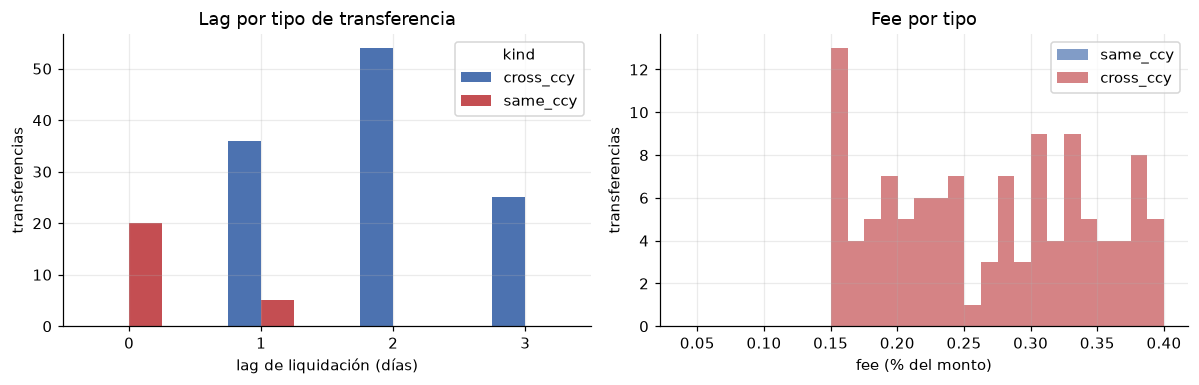

In [26]:
prof = transfers.groupby("kind").agg(
    n=("amount", "size"), lag_min=("lag_days", "min"), lag_mediana=("lag_days", "median"), lag_max=("lag_days", "max"),
    fee_min_pct=("fee_rate", lambda s: s.min() * 100), fee_media_pct=("fee_rate", lambda s: s.mean() * 100), fee_max_pct=("fee_rate", lambda s: s.max() * 100),
)
display(prof)
fig = plots.fig_lag_fee(transfers); plt.show()

- **Misma moneda:** fee **exactamente 0,04%** y lag 0–1 días. **Cross-moneda:** fee 0,15–0,40% (media ≈ 0,27%) y lag 1–3 días.
  Mover dinero dentro de la misma moneda es ~7× más barato y más rápido: cada cuenta operativa tiene una reserva de su misma moneda.
- Una transferencia ordenada hoy **no** cubre un faltante de hoy; el squad no modela el lag y por eso su regla se dispara todos los días sobre el mismo faltante (no ve lo que ya está en tránsito).
- La *tasa* del fee no decrece con el monto (correlación ≥ 0 dentro de cada moneda; un componente fijo la haría bajar) ⇒ **el costo fijo por operación no es observable en los datos**; es un supuesto declarado.

### D10 · Validación circular: promedio de saldos antes/después del 1-mayo, sumando COP+USD+MXN
Es el defecto más grave: no hay contrafactual, la métrica es la equivocada y suma monedas.

In [27]:
pp = D.pre_post(squad["balances"], panel, accounts)
display(pp)
w = D.currency_weight_in_squad_mean(squad["balances"], accounts)
print("Peso de cada moneda en el 'promedio de saldos' del squad:", {k: f"{v:.1%}" for k, v in w.items()})
print(f"\nSu propia celda imprime 'Looks like it's working, balances are up {pp.loc[0, 'cambio_%']:.1f}%': un −9,6% presentado como éxito.")

,vista,antes,despues,cambio_%
0,"squad: COP+USD+MXN sumados, datos crudos","1,068,097,438.63","965,805,394.31",-9.58
1,"COP solo, datos limpios","3,236,662,799.48","2,816,070,130.04",-12.99
2,"USD solo, datos limpios","191,614.35","133,182.93",-30.49
3,"MXN solo, datos limpios","105,498,451.19","74,878,102.93",-29.02


Peso de cada moneda en el 'promedio de saldos' del squad: {'COP': '97.0%', 'MXN': '3.0%', 'USD': '0.0%'}

Su propia celda imprime 'Looks like it's working, balances are up -9.6%': un −9,6% presentado como éxito.


1. **Suma monedas:** el "promedio" es ~97% pesos colombianos por pura magnitud nominal; USD y MXN no cuentan.
2. **Métrica equivocada:** un saldo más alto no es éxito (es costo de oportunidad) y uno más bajo no es fracaso; lo que importa es faltantes evitados vs. costo.
3. **Sin contrafactual:** antes/después confunde la política con la tendencia (los saldos derivan a la baja en *todas* las cuentas, −13% a −30% por moneda) y con la estacionalidad. Además, los datos muestran que el log de transferencias **ni siquiera está reflejado en los saldos** (Parte 2.1): no hay evidencia de que se haya rebalanceado el 1-mayo.

La forma correcta de evaluar es un **backtest walk-forward contra un contrafactual, con métricas de riesgo y de costo por moneda** (2.7).

---
# Parte 2 · Un enfoque sólido a la pregunta real

*(2.0–2.2 — formulación, reconciliación del log de transferencias y estructura de los flujos — quedan pendientes en este borrador; ver `notebooks/flawed_model_squad_draft_v3.ipynb` para una versión que sí las desarrolla.)*


## 2.0 · Formulación (qué significa "faltante" y cómo se decide)

*Pendiente en este borrador.*

## 2.1 · Reconciliación: ¿el log de transferencias explica algo de los saldos?

*Pendiente en este borrador.*

## 2.2 · Estructura de los flujos

*Pendiente en este borrador.*

## 2.3 · Forecast probabilístico: escalera de modelos con backtest walk-forward

,MAE diario / baseline,pinball diario / baseline,MAE acumulado / baseline,pinball acumulado / baseline,cobertura p5–p95 (acumulado),cobertura p5–p95 (diaria)
model,,,,,,
empirical,0.68,0.69,0.68,0.66,0.93,0.93
seasonal_naive,1.00,1.00,1.00,1.00,0.90,0.92
ets,0.72,0.73,0.74,0.74,0.93,0.93
sarimax,0.72,0.71,0.72,0.67,0.93,0.92
prophet,0.73,0.72,0.80,0.77,0.87,0.91


warnings de convergencia registrados (no silenciados): {'empirical': 0, 'seasonal_naive': 0, 'ets': 0, 'sarimax': 0, 'prophet': 0}


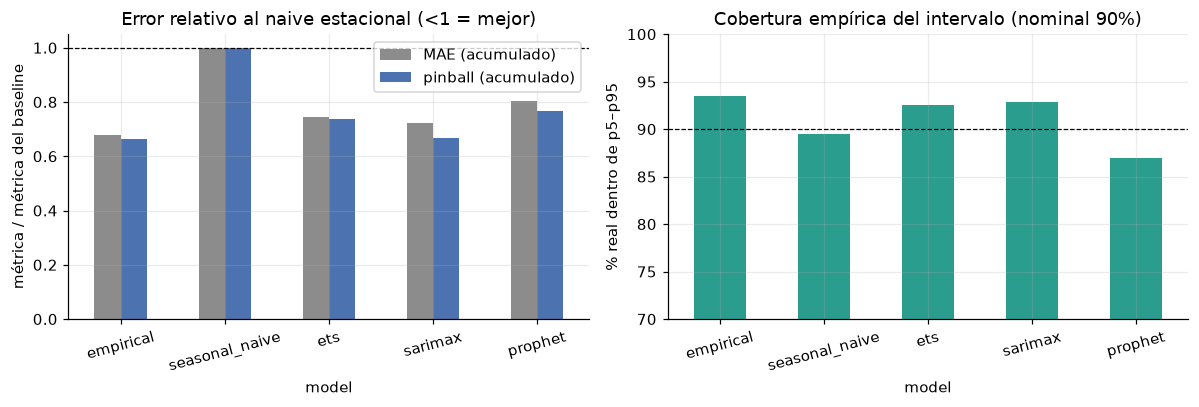


Modelo elegido por métrica (el más simple que gana al baseline y queda a ≤2% del mejor pinball acumulado): 'empirical'


In [28]:
scores, wf = F.compare_models(flows)
chosen, summary = F.select_model(scores)
display(summary.rename(columns={
    "mae_daily_rel": "MAE diario / baseline", "pinball_daily_rel": "pinball diario / baseline",
    "mae_cum_rel": "MAE acumulado / baseline", "pinball_cum_rel": "pinball acumulado / baseline",
    "cover_cum": "cobertura p5–p95 (acumulado)", "cover_daily": "cobertura p5–p95 (diaria)"}))
print("warnings de convergencia registrados (no silenciados):", {m: r["n_warnings"] for m, r in wf.items()})
fig = plots.fig_model_skill(summary); plt.show()
print(f"\nModelo elegido por métrica (el más simple que gana al baseline y queda a ≤{cfg.MODEL_TOLERANCE:.0%} del mejor pinball acumulado): {chosen!r}")

**Lectura.** Los cuatro modelos ganan claramente al naive estacional (**~26–34% menos pinball acumulado**), y no por sofisticación: el naive *inyecta ruido* (repite el flujo neto de hace una semana, que casi no tiene señal, y duplica la varianza del error).
Pero **ni ETS, SARIMAX ni Prophet le ganan a `empirical`** en pinball acumulado (la pérdida que importa para dimensionar un buffer) y su cobertura no es mejor. Por regla de decisión (*el más simple que gane al baseline*), **se queda `empirical`**.
Es un resultado incómodo pero honesto: **en estos datos la media del flujo neto no es predecible más allá de su deriva histórica; el valor está en la distribución calibrada**, no en el punto.

In [29]:
rel = F.skill_vs_baseline(scores)
cols = ["account_id", "h", "mae_cum", "mae_cum_rel", "pinball_cum", "pinball_cum_rel", "cover_daily", "cover_cum", "below_p5_cum", "above_p95_cum"]
tab = rel[rel["model"] == chosen][cols].set_index(["account_id", "h"])
display(tab.rename(columns={"mae_cum_rel": "MAE / baseline", "pinball_cum_rel": "pinball / baseline"}))
by_h = scores[scores["model"] == chosen].groupby("h")[["cover_daily", "cover_cum"]].mean()
display(by_h)
print(f"Cobertura empírica del intervalo p5–p95 (esperado ≈ 90%): diaria {scores[scores.model==chosen].cover_daily.mean():.1%}, "
      f"acumulada {scores[scores.model==chosen].cover_cum.mean():.1%}. Sobre el 90% nominal ⇒ ligeramente conservador (buffers algo holgados, del lado seguro).")

mae_cum  MAE / baseline   pinball_cum  pinball / baseline  cover_daily  cover_cum  below_p5_cum  above_p95_cum
account_id h                                                                                                                       
ACC-001    7  135,851,991.24            0.69 43,900,486.61                0.72         0.87       0.90          0.05           0.05
           14 200,816,478.21            0.54 64,851,570.82                0.53         0.87       0.89          0.07           0.05
ACC-002    7        6,847.55            0.73      2,058.04                0.68         0.93       0.94          0.05           0.02
           14       9,900.57            0.65      2,844.02                0.57         0.93       0.95          0.04           0.01
ACC-003    7   99,450,849.99            0.69 31,147,833.24                0.67         0.88       0.92          0.06           0.02
           14 146,488,568.83            0.61 44,146,568.77                0.55         0.89       0.90          0.06           0.04
ACC-004    7    2,069,873.91            0.71    803,824.02                0.75         0.99       0.99          0.01           0.00
           14   3,106,893.16            0.63  1,268,179.41                0.73         0.99       1.00          0.00           0.00
ACC-005    7    4,297,835.71            0.78  1,300,329.31                0.74         0.94       0.91          0.08           0.01
           14   6,507,568.86            0.66  1,962,610.11                0.62         0.94       0.92          0.07           0.01
ACC-006    7        7,475.88            0.76      2,413.45                0.74         0.97       0.95          0.02           0.03
           14      11,517.85            0.71      3,709.28                0.67         0.97       0.93          0.05           0.02

,cover_daily,cover_cum
h,,
7,0.93,0.94
14,0.93,0.93


Cobertura empírica del intervalo p5–p95 (esperado ≈ 90%): diaria 93.1%, acumulada 93.5%. Sobre el 90% nominal ⇒ ligeramente conservador (buffers algo holgados, del lado seguro).


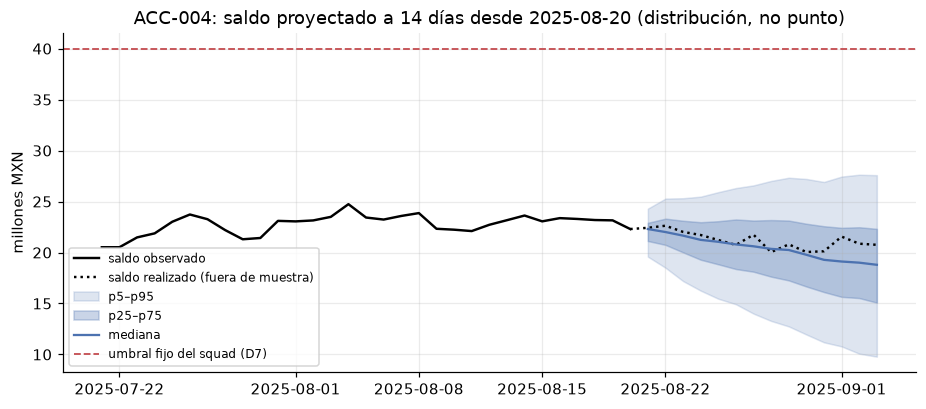

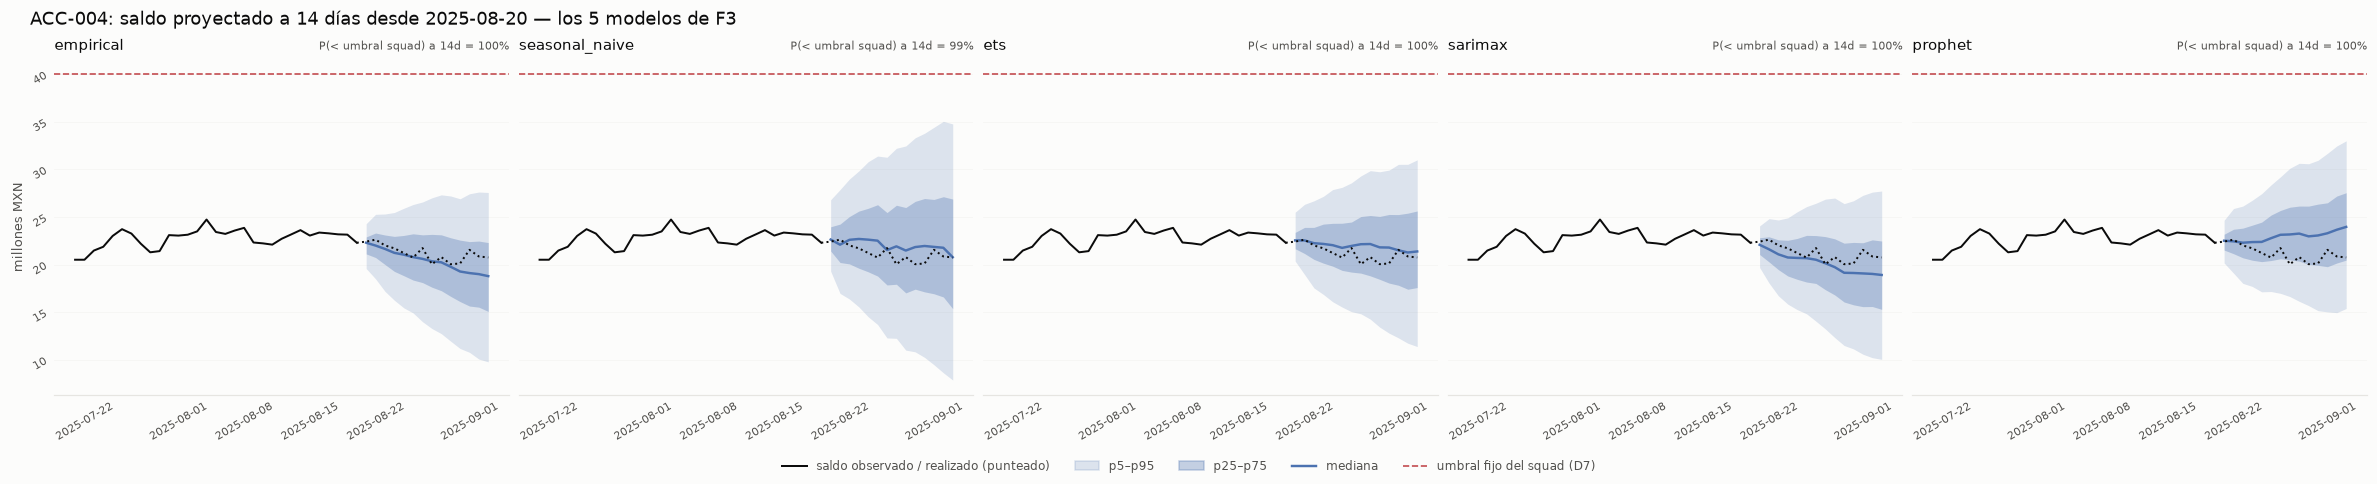

In [30]:
t_fan = list(book.dates).index(pd.Timestamp("2025-08-20"))
fig = plots.fig_fan(book, store, t_fan, "ACC-004"); plt.show()
fig = plots.fig_fan_models(book, flows, t_fan, "ACC-004"); plt.show()   # el mismo origen, los 5 modelos de F3 lado a lado

---
## 2.4–2.7 (resumen) · Dos reglas para no incumplir el piso, y la pregunta del fee vs. la multa

Con el forecast ya elegido (`empirical`, F3) monto las dos reglas de decisión de la Parte 2 y respondo la pregunta de negocio directamente:
**¿conviene transferir para evitar el faltante, o es más barato absorber la penalización por incumplir el piso?**

**Faltante := saldo proyectado < piso** (`book.floor`, K=25 días de egreso medio — supuesto propio, declarado en la Parte 0, no en el enunciado).
El motor de costos ya definido en `src/config.py` pone precio a las dos alternativas:

| Alternativa | Costo |
|---|---|
| Transferir | fee variable (0,04% misma moneda, 0,15–0,40% cross) + **USD 25 fijos por operación** (`cfg.FIXED_COST_USD`) |
| No transferir y quedar en faltante | **0,2% del déficit por cuenta-día** (`cfg.DEFICIT_PENALTY_PER_DAY`), ponderado 1,0 en cuentas operativas y 0,5 en reserva (`cfg.PENALTY_WEIGHT`) |

Dos reglas, ambas ya implementadas en `src/` (nada nuevo se define aquí), deciden con ese precio de por medio:

**Regla 1 — Política de cuantil (`P.QuantilePolicy`, Capa 1, la que se explica a Tesorería).** Proyecta el saldo a `DECISION_HORIZON` días
con el forecast; si el cuantil p5 cae bajo el piso de alguna cuenta alcanzable por una transferencia nueva, la cubre con el donante de mayor
excedente (reserva antes que operativa, misma moneda primero). Es una regla fija: transfiere siempre que hay riesgo de faltante, sin comparar
el costo de la transferencia contra la penalización.

**Regla 2 — MILP a horizonte rodante (`O.LPPolicy`, Capa 2, la que se explica al data scientist).** Minimiza
`fee + costo fijo + penalización esperada del déficit` sobre escenarios muestreados del forecast (SAA), reoptimizando cada día. A diferencia
de la regla 1, sí compara los dos costos explícitamente y puede decidir **no transferir** cuando cubrir cuesta más que la penalización esperada
— la pregunta del enunciado, resuelta caso por caso en vez de con una regla fija.

In [31]:
policy_b = P.QuantilePolicy()
policy_c = O.LPPolicy()
results = B.run_policies(book, store, [B.NoTransfers(), P.SquadRule(), policy_b, policy_c])
by_ccy, totals = B.compare(results)
totals.set_index("politica")[["n_transferencias", "fees_usd", "costo_fijo_usd", "costo_total_usd",
                               "dias_cuenta_en_faltante", "deficit_usd_dias", "penalizacion_usd"]]

,n_transferencias,fees_usd,costo_fijo_usd,costo_total_usd,dias_cuenta_en_faltante,deficit_usd_dias,penalizacion_usd
politica,,,,,,,
0: sin transferencias,0,0.00,0.00,0.00,33,"5,215,399.43","10,429.89"
A: regla del squad,200,"1,275.36","5,000.00","6,275.36",86,"7,106,479.21","13,912.16"
B: cuantil p5,49,"3,729.77","1,225.00","4,954.77",0,0.00,0.00
C: MILP λ=0.002,22,"1,548.73",550.00,"2,098.73",0,0.00,0.00


**Lectura.** Sin transferir, el sistema acumula 33 días-cuenta en faltante (USD 5,2 millones·día de déficit), que a la penalización
declarada equivalen a **USD 10,4 mil** — y eso sin pagar un solo fee. La regla del squad (D7) no lo arregla: lo empeora (86 días-cuenta,
penalización implícita USD 13,9 mil) porque transfiere en la moneda del donante en vez de la del destino (D6) y sin respetar el lag (D8),
además de pagar USD 6,3 mil en fees y costo fijo por 200 transferencias que en su mayoría no resuelven nada.

Las dos reglas correctas sí llevan el déficit a cero, y ahí el costo se vuelve una comparación limpia entre transferir y la penalización que
evitan: la política de cuantil lo logra por **USD 5,0 mil** (49 transferencias) y el MILP por **USD 2,1 mil** (22 transferencias) — 58% más
barato, porque además de resolver el mismo faltante compara, transferencia por transferencia, si vale la pena hacerla.

In [32]:
log = pd.DataFrame(policy_c.log)
print(f"El MILP evalúa un faltante proyectado y decide NO transferir {len(log)} veces en el backtest.")
display(log["motivo"].value_counts().rename("días-cuenta"))

cheaper = log[log["penalizacion_esperada_usd"] < log["costo_minimo_de_cubrir_usd"]]
print(f"\nEn {len(cheaper)} de {len(log)} ({len(cheaper) / len(log):.0%}) casos, la multa esperada es menor que el costo mínimo de cubrir el "
      f"faltante (USD {log['penalizacion_esperada_usd'].mean():.2f} vs USD {log['costo_minimo_de_cubrir_usd'].mean():.2f} en promedio, sobre estas filas).")
cheaper.sort_values("deficit_esperado_usd_dias", ascending=False)[
    ["fecha", "cuenta", "moneda", "penalizacion_esperada_usd", "costo_minimo_de_cubrir_usd", "motivo"]
].head(8)

El MILP evalúa un faltante proyectado y decide NO transferir 397 veces en el backtest.


motivo
penalización esperada ≤ costo fijo de operar           227
el MILP no transfiere: costo > penalización evitada    170
Name: días-cuenta, dtype: int64


En 324 de 397 (82%) casos, la multa esperada es menor que el costo mínimo de cubrir el faltante (USD 20.30 vs USD 27.17 en promedio, sobre estas filas).


,fecha,cuenta,moneda,penalizacion_esperada_usd,costo_minimo_de_cubrir_usd,motivo
346,2025-08-27,ACC-005,MXN,32.32,32.70,el MILP no transfiere: costo > penalización evitada
107,2025-05-08,ACC-005,MXN,32.22,32.76,el MILP no transfiere: costo > penalización evitada
138,2025-05-22,ACC-005,MXN,30.18,31.25,el MILP no transfiere: costo > penalización evitada
155,2025-05-29,ACC-006,USD,25.23,27.10,el MILP no transfiere: costo > penalización evitada
276,2025-07-26,ACC-005,MXN,25.05,30.10,el MILP no transfiere: costo > penalización evitada
312,2025-08-15,ACC-005,MXN,23.90,29.82,el MILP no transfiere: costo > penalización evitada
151,2025-05-27,ACC-006,USD,22.33,27.18,penalización esperada ≤ costo fijo de operar
152,2025-05-28,ACC-005,MXN,21.61,28.16,penalización esperada ≤ costo fijo de operar


**¿Es más barato pagar la multa que el fee? Depende de la escala.**

- **Faltante por faltante: casi siempre sí.** De los 397 faltantes proyectados que el MILP evalúa y decide no cubrir, en el 82% (324) la
  penalización esperada es menor que el costo mínimo de cubrirlo (fee + USD 25 fijos) — en promedio USD 20 de multa esperada contra USD 27
  de costo de operar. El 57% de esos casos (227 de 397) ni siquiera superan el costo fijo de la operación: mover dinero para evitar un
  faltante de unos pocos dólares esperados no se justifica.
- **Acumulado en el tiempo: no.** El "no hacer nada" del contrafactual deja 33 días-cuenta en faltante y una penalización implícita de
  USD 10,4 mil — más del doble de lo que cuesta resolverlo del todo con el MILP (USD 2,1 mil). La multa sale barata por decisión individual
  precisamente porque son montos pequeños y acotados al horizonte de decisión (`DECISION_HORIZON` días); dejada correr sin ningún control
  sobre 210 días × 6 cuentas, se acumula más de lo que cuesta simplemente rebalancear con criterio.

En otras palabras: la multa gana partido a partido, el fee gana el torneo. Por eso el MILP no es "nunca transferir" ni "siempre transferir":
es la regla que compara las dos, día a día y cuenta por cuenta — y esa comparación, no un umbral fijo, es lo que evita la penalización.

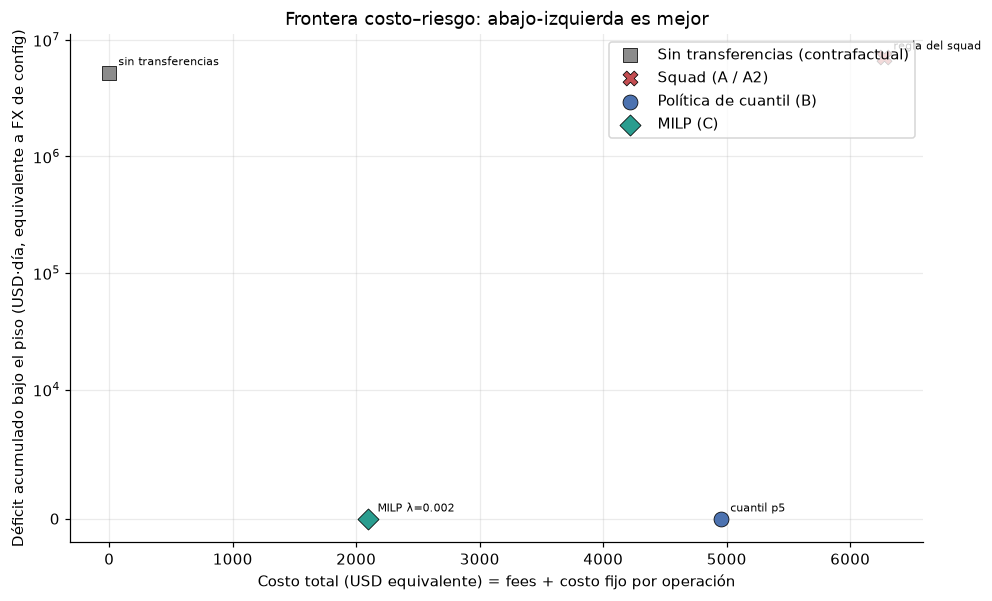

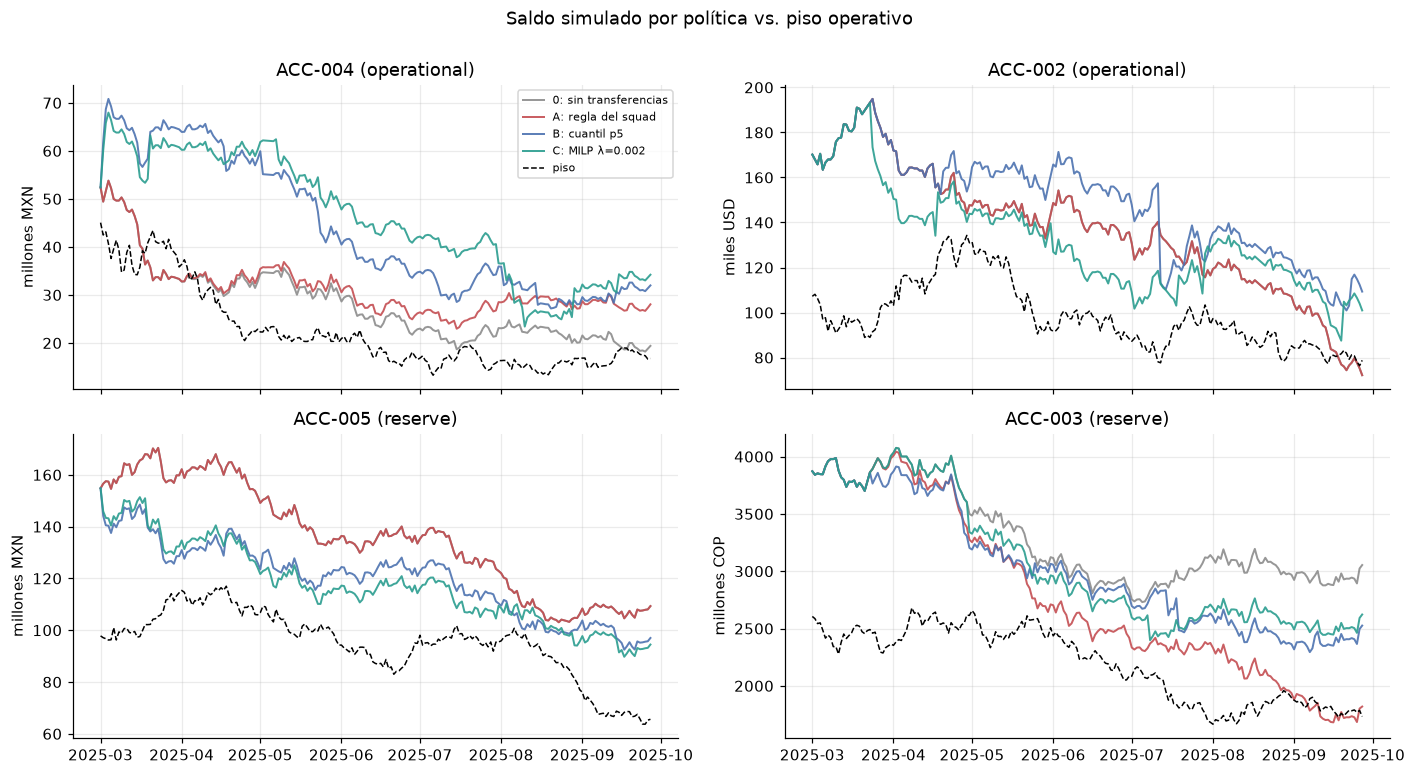

In [33]:
totals_f = totals.assign(familia=totals["politica"].str[0])
plots.fig_frontier(totals_f); plt.show()
plots.fig_policy_paths(results, book); plt.show()

---
## 2.8 · Motor de rebalanceo: cuándo, desde dónde y cuánto

Parto de la formulación clásica de inventarios (punto de reorden + stock de seguridad) y la adapto a
liquidez sobre el forecast elegido en 2.3: bootstrap empírico de flujos netos, que ningún modelo
paramétrico superó en pinball loss en el backtest walk-forward. El motor tiene tres decisiones
secuenciales, en este orden, porque cada una depende de la anterior.

**Notación.** $i$ cuenta receptora, $j$ donante, $b = 1..N$ trayectorias bootstrap,
$\alpha$ nivel de servicio, $L_{ji}$ lag p90 observado para el par ($j \to i$), $R = 1$ período de
revisión (corrida diaria), $\text{piso}_i$ = `book.floor` (K × egreso medio 28 días, Parte 0).

$$B^{(b)}_{i,t+k} = B_{i,t} + \sum_{s=1}^{k} y^{(b)}_{i,t+s} + T^{\,tránsito}_{i,t+k}$$

**A. ¿Cuándo? — trigger sobre la trayectoria, no sobre un punto**

$$\text{Alerta}_i \iff Q_\alpha\!\Big(\min_{1 \le k \le \bar L_i + R} B^{(b)}_{i,t+k}\Big) < \text{piso}_i
\qquad \bar L_i = \max_j L_{ji}$$

El trigger usa el lag máximo del receptor, no el del donante: así se decide *si* hay que actuar antes
de decidir *con quién*, y se rompe la circularidad.

Relación con la fórmula clásica: con flujos i.i.d. $\mathcal N(\mu,\sigma^2)$ y evaluando solo el punto
final, $Q_\alpha(B_{t+L+R}) = \hat B_{t+L+R} - z_\alpha\,\sigma\sqrt{L+R}$, que recupera
$SS = \text{piso} + z_\alpha\sigma\sqrt{L+1}$. El $+1$ es el período de revisión. Aquí se reemplaza en
dos sentidos: (i) cuantil empírico en lugar de normal, porque los flujos tienen estacionalidad semanal
y colas asimétricas; (ii) **mínimo sobre la trayectoria** en lugar del punto final, porque un faltante
en $t+1$ no se compensa con un superávit en $t+L$.

**B. ¿Desde dónde? — ruta más barata que llegue a tiempo**

Sea $k^*$ el primer día en que el cuantil $\alpha$ cruza el piso. Un donante $j$ es factible si:

1. llega a tiempo: $L_{ji} < k^*$;
2. no se pone en riesgo a sí mismo: tras el débito, $Q_\alpha(\min_k B^{(b)}_{j,t+k}) \ge \text{piso}_j$;
3. se prefiere `reserve` sobre `operational` como fuente.

Entre los factibles se elige el de menor costo $c_{ji}(m) = F + f_{ji}\cdot m$. En estos datos eso
ordena las rutas de forma casi determinística: **misma moneda** (fee mediano 0,040 %, lag mediano 0)
antes que **cruce** (0,274 %, lag 2).

**C. ¿Cuánto? — el monto que sostiene el cuantil sobre el horizonte $H$**

$$m_{ji} = \max\!\Big(m_{\min},\; \text{piso}_i - Q_\alpha\!\Big(\min_{L_{ji} \le k \le L_{ji}+H} B^{(b)}_{i,t+k}\Big)\Big)$$

Como el monto desplaza todas las trayectorias por igual desde su llegada, sumar $m$ sube el cuantil
del mínimo exactamente en $m$: el sizing es exacto, no una aproximación. Frente a
$Target = SS + H\mu_{burn}$ de la versión anterior, esta forma incorpora el ensanchamiento de la
incertidumbre a lo largo de $H$ y no solo la deriva media. El débito en origen es $m / FX_{j\to i}$,
acotado por el excedente del donante sobre su propio piso.

**D. Elección de $H$**

$H$ equilibra costo fijo por operación contra caja ociosa: el análogo EOQ da
$H^* \approx \sqrt{2F / (h\,|\mu_i|)}$, con $h$ costo de oportunidad diario. Como $F$ y $h$ son
supuestos declarados (§7), $H$ se calibra sobre la frontera costo–riesgo del backtest, no por la fórmula.

**E. Casos que el motor debe declarar, no esconder**

- **Faltante inevitable**: $k^* \le \min_j L_{ji}$. Ninguna transferencia llega a tiempo → escala a
  Tesorería (línea de crédito, gestión manual).
- **Sin donante factible**: todos los candidatos quedarían bajo su propio piso → escala.

Implementado en `P.target_buffer(ctx, cuenta, donante, alpha, H)` ([`src/policy.py`](../src/policy.py)).
El notebook solo lo muestra.

In [34]:
from scipy.stats import norm

print(f"Z=2.33 <-> alpha = {1 - norm.cdf(2.33):.4f} (99% de confianza, una cola)")
print(f"alpha=0.01 <-> Z = {norm.ppf(0.99):.4f}")
print(f"\npiso_i = book.floor (K={cfg.MIN_COVER_DAYS} días de egreso medio de {cfg.OUTFLOW_WINDOW_DAYS}d)")
print(f"L_i = book.lag_plan por par de cuentas: {cfg.LAG_PLAN}")
print(f"H = cfg.DECISION_HORIZON = {cfg.DECISION_HORIZON} días")

Z=2.33 <-> alpha = 0.0099 (99% de confianza, una cola)
alpha=0.01 <-> Z = 2.3263

piso_i = book.floor (K={'operational': 25.0, 'reserve': 25.0} días de egreso medio de 28d)
L_i = book.lag_plan por par de cuentas: {'same_ccy': 1, 'cross_ccy': 3}
H = cfg.DECISION_HORIZON = 14 días


### Caso real: 2025-05-06 — un "esperar" y dos "transferir" el mismo día

Origen con mezcla real de los tres estados (`P.WaitAwarePolicy(alpha=0.01).opportunities(ctx)`, que ya implementa
el trigger de arriba con el cuantil empírico p1 en vez de la campana):

In [35]:
t_case = list(book.dates).index(pd.Timestamp("2025-05-06"))
ctx_case = B.context_at(book, store, t_case)
opp = P.WaitAwarePolicy(alpha=0.01).opportunities(ctx_case)
opp[["saldo_hoy", "piso", "p1_minimo", "estado", "holgura_dias", "primer_dia_bajo_piso", "ultimo_dia_para_solicitar"]]

,saldo_hoy,piso,p1_minimo,estado,holgura_dias,primer_dia_bajo_piso,ultimo_dia_para_solicitar
cuenta,,,,,,,
ACC-001,"2,401,191,348.30","1,588,422,741.69","1,819,026,746.57",ok,NaN,None,None
ACC-002,"147,749.79","122,790.45","113,122.59",esperar,3.00,2025-05-13,2025-05-10
ACC-003,"3,482,599,465.86","2,394,307,628.48","2,982,700,090.21",ok,NaN,None,None
ACC-004,"34,553,648.40","23,165,301.22","13,793,302.42",transferir,0.00,2025-05-10,2025-05-07
ACC-005,"144,613,014.08","108,080,420.09","121,963,608.87",ok,NaN,None,None
ACC-006,"148,343.19","130,878.22","97,031.26",transferir,0.00,2025-05-10,2025-05-07


**Lectura.** El cuantil p1 perfora el piso en tres cuentas, pero el trigger de arriba no las trata igual:

- **ACC-002 (USD, operational) → esperar.** El p1 (USD 113 mil) cae bajo el piso (USD 123 mil), pero la
  **mediana** proyectada nunca lo hace — el faltante vive solo en la cola. Con 3 días de holgura entre lo que
  tarda el fondeo (lag 3d) y el primer día de faltante (2025-05-13), se puede esperar y reevaluar mañana con el
  forecast reoptimizado: exactamente la regla de espera del MILP (2.6) aplicada como regla fija.
- **ACC-004 (MXN, operational) y ACC-006 (USD, reserve) → transferir ya.** Holgura = 0: el primer día de faltante
  coincide con el primer día en que una transferencia pedida hoy podría llegar. No hay margen para esperar y ver
  qué pasa; el trigger dispara de inmediato.

In [36]:
donor = book.accounts.index("ACC-003")   # único donante con excedente en este origen (ver abajo)
rows = []
for acc in ("ACC-002", "ACC-004", "ACC-006"):
    a = book.accounts.index(acc)
    r = P.target_buffer(ctx_case, a, donor, alpha=0.01)
    r["cuenta"] = acc
    rows.append(r)
pd.DataFrame(rows).set_index("cuenta")[["lag_dias", "piso", "b_hat_alpha", "mu_burn_diario", "target_buffer_H", "monto_requerido"]]

,lag_dias,piso,b_hat_alpha,mu_burn_diario,target_buffer_H,monto_requerido
cuenta,,,,,,
ACC-002,3,"122,790.45","111,448.63",-0.00,"122,790.45","11,341.81"
ACC-004,3,"23,165,301.22","13,015,377.38",-0.00,"23,165,301.22","10,149,923.84"
ACC-006,3,"130,878.22","98,189.54",-0.00,"130,878.22","32,688.68"


**Lectura del sizing.** `mu_burn_diario ≈ 0` en las tres cuentas: confirma, con números de este origen concreto,
lo que 2.3 ya estableció (el flujo neto medio no tiene deriva explotable). Todo el "Monto Requerido" viene del
colchón por incertidumbre de liquidación (el cuantil empírico en el peor día alcanzable), no de extrapolar un
burn rate — el término $H\cdot\mu_{burn}$ de la fórmula es correcto mantenerlo (protege datasets con tendencia
real), pero en **este** dataset no aporta.

Comparado con el sizing mínimo que ya usa `QuantilePolicy` (cubre el faltante + `MIN_TRANSFER_DAYS_OF_OUTFLOW` de
margen, sin colchón a `H` días): para ACC-006 pide USD 13.430 recibidos vs. los **USD 32.689** de `target_buffer`
— 2,4× más, a cambio de no tener que volver a transferir en los próximos 14 días en vez de en los próximos ~2.
Es el trade-off explícito frente a `saldo_ocioso_prom` (2.7): menos operaciones, más plata parada.

**Y una falla real de fondeo, no de regla.** `QuantilePolicy` en este mismo origen **no** logra cubrir a ACC-004:
el único donante con excedente es ACC-003 (COP, reserva), y su excedente donable (~COP 109,5 millones) casi se
agota cubriendo ACC-002 y ACC-006 primero (COP 56,9 M + 52,4 M ≈ COP 109,3 M) — no por un umbral mal puesto ni
por falta de una regla mejor, sino porque **no hay suficiente liquidez donable** en esta moneda ese día. Es el
mismo fenómeno que la sensibilidad de 2.8 reporta con el piso de 30 días: en algunos días el problema deja de ser
de rebalanceo y pasa a ser de fondeo — aquí ocurre incluso con el piso base (K=25).

---
## 2.9 · Sensibilidad

*Cifras de una corrida de referencia (`CONCLUSIONES_Y_PENDIENTES.md`); pendiente reproducirlas dentro de este notebook.*

- **Robusto a FX ±10%** y a forzar el lag cross-currency a 3 días: el MILP se mantiene en 0 días-cuenta en faltante.
- **Frágil a sesgo del forecast.** Con un sesgo optimista de +0,5σ (el modelo subestima egresos futuros) aparecen 1 día-cuenta
  en faltante con la política de cuantil y 3 con el MILP. Es la sensibilidad que más pesa: `empirical` hereda el sesgo de la
  historia sin corregirlo, así que un cambio de régimen no detectado se traduce directo en faltantes.
- **Con piso K=30 días el problema deja de ser de rebalanceo.** El excedente agregado del sistema baja a ~USD 58 mil: ninguna
  política de transferencias lo resuelve, porque no hay de dónde mover — es un problema de fondeo, no de asignación.

## 2.10 · Dónde puede seguir fallando

- **6 episodios de 3 días sin explicar** (caídas de 65–85% con rebote) quedaron en cuarentena, no reconciliados. Si son eventos
  reales de negocio y no errores de registro, el riesgo de faltante que reporta el backtest está subestimado.
- **El log de transferencias no aparece en los saldos** (140 transferencias, ninguna explica un residuo de la identidad
  contable). No se sabe qué representan; el forecast de flujo neto podría estar ignorando movimientos que en producción sí
  impactan el saldo.
- **λ (penalización por déficit) se calibró mirando la misma historia que se evalúa** — sin validación fuera de muestra. La
  decisión del MILP de "pagar la multa en vez de transferir" es sensible a este número, que Tesorería aún no ha confirmado.
- **Supuesto de exogeneidad.** Los flujos no se reajustan cuando se mueve saldo entre cuentas (en los datos, el egreso parece
  escalar con el nivel del saldo, ~35 días de cobertura). Si eso no se sostiene en producción, mover dinero podría cambiar el
  comportamiento que el forecast asume fijo.
- **La TRM del COP (3.900) es aproximada, no la tasa oficial.** Cualquier decisión de donante o monto en USD equivalente
  hereda ese error.
- **El piso K=25 días es un supuesto propio** ([DECISIÓN HUMANA] en `config.py`), no validado por Tesorería — cambia
  directamente qué cuenta cuenta como "en faltante".

---
# Parte 3 · Dos explicaciones de lo mismo

Mismo resultado, dos audiencias: metodología y supuestos para quien va a mantener el modelo; costo, riesgo y qué se le pide
que confirme para quien va a operar con él.

## 3.1 · Para el data scientist del squad

- **Qué estaba mal:** el pipeline pierde 17,6% de las filas por un `dropna` silencioso tras `coerce`, trata 9 etiquetas de
  moneda como 9 monedas distintas, y el forecast (media móvil 14d del **nivel**) es peor que el naive "saldo de mañana = saldo
  de hoy" — sin drift, sin estacionalidad, sin incertidumbre. El donante se elige por saldo nominal sin convertir FX.
- **Qué cambia:** se modela el **flujo neto**, no el nivel, con una escalera de modelos (naive estacional → ETS → SARIMAX →
  Prophet → bootstrap empírico) validada con `TimeSeriesSplit` walk-forward, sin fuga de información. Gana `empirical`:
  ningún modelo paramétrico supera a un bootstrap de residuos históricos — la media del flujo neto no tiene señal explotable
  más allá de su deriva; el valor está en la **distribución** (cuantiles p5–p95, cobertura ≈93%).
- **Motor de decisión, dos capas sobre el mismo forecast:** una política de cuantil (buffer = cuantil bajo del saldo
  proyectado, la que se explica a Tesorería) y un MILP a horizonte rodante de 14 días que minimiza
  `fee + costo fijo + penalización esperada del déficit`, reoptimizando cada día y decidiendo explícitamente cuándo es más
  barato pagar la penalización que transferir.
- **Supuestos explícitos** (`src/config.py`, no en el código de modelado): piso K=25 días de egreso medio (28d), fee
  0,04%/0,27% (misma moneda/cruce), lag 1/3 días (p90 observado por tipo de par), costo fijo USD 25, penalización 0,2% del
  déficit por cuenta-día, TRM COP=3.900 (no oficial).
- **Dónde puede fallar:** el bootstrap asume que los residuos históricos por tipo de día representan bien el futuro — un
  cambio de régimen no lo captura, y es la sensibilidad que más duele (2.9). λ se calibró en la misma muestra que se evalúa,
  sin validación fuera de muestra (2.10).

## 3.2 · Para Tesorería

- **Qué hace el sistema:** todos los días revisa si alguna cuenta se va a quedar corta de dinero antes de que llegue una
  transferencia nueva —contando cuánto tarda esa transferencia según sea la misma moneda o un cruce de divisa— y, si es así,
  mueve solo lo necesario desde la cuenta con más excedente, priorizando la fuente más barata y más rápida.
- **Qué mejora frente al modelo anterior:** el modelo del squad, aplicado sobre el mismo histórico, deja **86 días-cuenta en
  déficit** (peor que no hacer nada). El nuevo enfoque deja **0 días-cuenta en déficit** con **menos de la mitad del costo**
  (≈USD 2.100 en fees y multas vs. USD 6.300 del squad), usando **22 transferencias** en vez de 200.
- **Una decisión que toma el sistema y que Tesorería debe validar:** a veces el sistema decide **no** mover dinero y absorber
  una multa pequeña, cuando mover el dinero costaría más que la multa esperada. Eso exige que el costo de la multa (0,2% del
  déficit por día) sea razonable — si Tesorería usa otro criterio de riesgo, ese número hay que ajustarlo.
- **Riesgo residual:** el pronóstico se basa en el comportamiento de los últimos ~9 meses; no anticipa eventos nuevos (un
  cliente grande, un cambio regulatorio). Además hay 6 caídas de saldo sin explicar en el histórico y 140 transferencias
  registradas que no se reflejan en los saldos — mientras no se aclaren con el banco, el riesgo real podría ser mayor al que
  reporta el backtest.
- **Qué necesita confirmar Tesorería antes de usarlo:** el piso mínimo de 25 días de egresos por cuenta, la tasa de cambio
  oficial del peso colombiano (hoy se usa un valor aproximado) y el costo fijo de USD 25 por operación.
- Se pretende buscar un pronostico quantilico para tener plena seguridad de los umbrales actuales no superen ciertos rangos de toleracia para tener un modelo a largo plazo.

---
# Parte 4 · Formas de trabajo: dónde se usó IA y dónde no
 Dónde sí se usó IA
- **Implementación (Claude Code):** pipeline de reconciliación, parser de fechas por formato, backtests, simulador de políticas y visualizaciones, construidos contra la spec.
- **Pruebas:** scaffolding de `pytest` (`test_data_integrity.py`); las aserciones las dicta la spec (identidad contable, unicidad, rangos).
- **Calidad de código:** linters, PEP 8 y estructura modular.
- **Revisión y síntesis (Claude, chat):** revisión crítica de la v2, condensación en dos notebooks autocontenidos y borradores de las explicaciones de la Parte 3.
- **Marco conceptual:** contraste del método con la teoría de inventarios (política (s, S), Arrow–Harris–Marschak) para fundamentar la banda de reposición.
- ** Refinar textos y ortografia.


Dónde no, a propósito
- La especificación, los criterios de aceptación y la formulación del problema.
- Los supuestos de negocio (K, α, costo fijo) y el punto de operación recomendado.
- La lectura de resultados y la recomendación a Tesorería. **La IA calcula; no decide cuánto riesgo se acepta.**

Cómo se verificó lo que produjo la IA
Nada se aceptó porque "corría sin error": ese es exactamente el fallo del notebook original. Cada entrega se validó contra la spec: identidad contable al centavo, conteos cruzados con los datos crudos, calibración separada de la evaluación y una celda final que verifica las afirmaciones del texto. La verificación detectó y corrigió errores reales:
- Se suponía que el log de transferencias estaba reflejado en los saldos; los datos lo refutaron. [confirmar]
- Una primera política hacía ping-pong entre cuentas; se corrigió con un margen para el donante.
- Una versión de la banda cruzaba monedas de más (7 de 10 transferencias); se corrigió midiendo la capacidad del donante con su mediana y reservando el cruce para faltantes del pool completo.

---
# Parte 5 · De notebook a producción (media página)

# Arquitectura de Producción, Monitoreo y Reentrenamiento Continuo para el Modelo de Liquidez

## 1. Objetivo Operativo y Estratégico

El proyecto tiene como propósito desplegar y operar un sistema predictivo de liquidez a horizontes de 7 y 14 días. La solución automatiza la estimación del flujo de caja para guiar las decisiones de fondeo y la optimización del rebalanceo de capital entre cuentas corporativas, minimizando el impacto de comisiones bancarias, evitando sanciones por saldos deficientes y maximizando la eficiencia operativa.

---

## 2. Pipeline de Datos y Arquitectura de Ingesta

El origen de la información se conecta de forma directa a las APIs bancarias y al *core* de saldos y movimientos en lugar de archivos estáticos, operando bajo contratos de datos estrictamente versionados. La orquestación se ejecuta diariamente tras el cierre bancario mediante un grafo dirigido acíclico (DAG en Airflow o Dagster) bajo el siguiente flujo:

$$\text{Ingesta} \longrightarrow \text{Validación} \longrightarrow \text{Pronóstico} \longrightarrow \text{Optimización/Política} \longrightarrow \text{Generación de Plan} \longrightarrow \text{Aprobación}$$

Antes de alimentar la fase de inferencia, se aplican controles de calidad bloqueantes:

* **Formato y Normalización:** Un *parser* de fechas en cascada detiene el proceso inmediatamente ante cualquier inconsistencia tipográfica o de estructura.
* **Integridad y Coherencia Primaria:** Se valida la unicidad de la clave `(fecha, cuenta)` y la alineación de las divisas contra el catálogo central.
* **Identidad Contable (Principio Zero-Loss):** Se verifica la ecuación fundamental:
  $$b[t] = b[t-1] + \text{entradas} - \text{salidas}$$
  Cualquier residuo superior a $1$ unidad detiene la corrida para garantizar cero pérdida de trazabilidad contable.
* **Frescura y Plausibilidad:** Se exige disponibilidad de datos del día en curso para el $100\%$ de las cuentas, junto con validaciones de rango lógico en saldos y tipos de cambio. Cualquier registro anómalo o incompleto es derivado a una cuarentena marcada para su revisión, impidiendo el descarte silencioso de datos.

---

## 3. Inferencia, Monitoreo de Degradación y Alertas de Drift

En cada ciclo, el sistema genera pronósticos continuos a 7 y 14 pasos para orientar los montos óptimos de transferencia entre cuentas. Dado que la dinámica del mercado y los patrones institucionales evolucionan, la salud del modelo se evalúa mediante un esquema de monitoreo continuo en tres dimensiones:

1. **Métricas de Desempeño:** Seguimiento de la desviación absoluta (MAE), el error porcentual simétrico (SMAPE) y la raíz del error cuadrático medio (RMSE) en ventanas móviles de 7 y 30 días, evaluando el desempeño de producción frente a las métricas de entrenamiento.
2. **Intervalos y Sensibilidad:** Evaluación de la *Pinball Loss* por cuenta e intervalo, monitoreando la cobertura del rango proyectado (p5–p95) con alertas operativas si la cobertura real se desvía del umbral de $85\%$ a $95\%$. Asimismo, se supervisa el sesgo direccional para evitar costos por sobre o sub-fondeo.
3. **Detección de Drift y Negocio:** Medición del Índice de Estabilidad de la Población (PSI) sobre los flujos netos respecto a la ventana base para detectar quiebres estructurales. En paralelo, se monitorea la tasa de faltantes reales frente a los predichos, la latencia real de liquidación de transferencias y la variación entre las comisiones ejecutadas y las presupuestadas.
4. Esquema shallow para ir cambiando modelos y evauando el performance con el negocio.

---

## 4. Reentrenamiento Continuo y Captura de Series Temporales

Para adaptar la estrategia de pronóstico de forma autónoma sin perder estabilidad, el pipeline incorpora un esquema de reentrenamiento continuo activado por tres tipos de disparadores (*triggers*):

* **Por Desempeño o Drift:** Disparo automático cuando las métricas de error (MAE/RMSE) superan los límites de tolerancia o cuando el PSI refleja variaciones sustanciales en la distribución de la serie (*Data/Concept Drift*).
* **Por Calendario:** Reentrenamiento programado mediante un *bootstrap* sobre ventana expansiva para integrar los comportamientos de mercado más recientes.

La ingeniería de atributos del modelo incorpora explícitamente variables exógenas como días hábiles, festivos, quincenas, cierres de mes/trimestre y fechas de pagos masivos. Paralelamente, se aplican algoritmos de filtrado para aislar *outliers* y shocks de liquidez no recurrentes (como aportes extraordinarios de capital), evitando que distorsionen la tendencia estacional del modelo. Toda nueva versión debe superar una validación automatizada mediante una estrategia **Champion-Challenger**, garantizando que el modelo retrenado solo reemplace al vigente en producción si demuestra un incremento estadísticamente significativo en su precisión.

---

## 5. Salvaguardas, Gobierno y Mecanismos de Contingencia

Por diseño de seguridad operativa, el sistema funciona en modo **Dry-Run por defecto**, generando recomendaciones que requieren la revisión y confirmación del analista de tesorería.

Las operaciones están sujetas a salvaguardas estrictas:

* **Aprobación Humana:** Protocolo obligatorio de autorización explícita cuando la transferencia supere los umbrales de riesgo definidos.
* **Reconciliación Post-Settlement:** Auditoría continua que compara las posiciones y saldos liquidados versus el plan recomendado.
* **Política de Contingencia y Fallback:** Si las métricas de monitoreo evidencian degradación, pérdida de frescura en las fuentes o sesgo elevado, el sistema activa un *kill switch* o cambia automáticamente a un modo manual basado en reglas conservadoras de negocio. Todos los planes generados, junto con sus motivos y supuestos de cálculo, se archivan de manera inmutable para fines de trazabilidad y auditoría.